# KnowYourLoan (Team Slytherin)
## Explainable Loan Prediction Approval: Predict. Explain. Simulate.
This notebook contains the complete pipeline for generating a high-quality, scientifically defensible, India-focused loan approval dataset, training candidate machine learning models (Logistic Regression, Random Forest, CatBoost), validating explainability with SHAP, and saving the final production-ready assets.

In [1]:
!pip install -q catboost shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix, brier_score_loss
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier, Pool

# Configure global parameters
SEED = 42
np.random.seed(SEED)

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
print(f"Environment initialized. Seed set to {SEED}.")

Environment initialized. Seed set to 42.


### 1. Data Generation Engine (India-Focused & Highly Learnable)
We construct realistic distributions with a strong, predictable financial signal based on:
1. **Affordability Strength** (low FOIR, healthy disposable income)
2. **Credit Strength** (high credit score, clean credit history)
3. **Employment Stability** (salaried/professionals, high years of employment)
4. **Financial Stability / Asset backing** (high savings and investments compared to loan request)
5. **Loan Burden / Leverage** (low loan amount relative to income, reasonable LTV)

We derive the EMI scientifically using the PMT formula:
$$EMI = P \times r \times \frac{(1+r)^n}{(1+r)^n - 1}$$

In [3]:
def calculate_emi(principal, annual_rate, tenure_months):
    # Calculate monthly EMI based on annual interest rate
    r = (annual_rate / 12) / 100
    n = tenure_months
    # Guard against division by zero or negative rates
    if r == 0:
        return principal / n
    return principal * r * ((1 + r)**n) / (((1 + r)**n) - 1)

def generate_loan_dataset(N, seed=SEED):
    np.random.seed(seed)

    # 1. Demographic & Basic Info
    age = np.random.randint(21, 71, size=N)
    gender = np.random.choice(['Male', 'Female'], size=N, p=[0.70, 0.30])
    marital_status = np.random.choice(['Single', 'Married', 'Divorced', 'Widowed'], size=N, p=[0.25, 0.65, 0.07, 0.03])
    dependents = np.random.choice([0, 1, 2, 3, 4], size=N, p=[0.30, 0.30, 0.25, 0.10, 0.05])
    education = np.random.choice(['12th', 'Diploma', 'Graduate', 'Postgraduate', 'Professional'], size=N, p=[0.10, 0.15, 0.50, 0.20, 0.05])
    employment_type = np.random.choice(['Salaried', 'Self-employed', 'Business owner', 'Professional', 'Contract'], size=N, p=[0.55, 0.15, 0.15, 0.10, 0.05])
    employment_years = np.clip(np.random.exponential(scale=6, size=N) + 1, 1, 45).astype(int)
    city_tier = np.random.choice(['Tier 1', 'Tier 2', 'Tier 3'], size=N, p=[0.40, 0.35, 0.25])

    # 2. Income Distributions (Right-Skewed with long tails representing Indian Rupees - INR)
    # Base monthly income centered around ~60k to 1.5L with a long tail stretching to 10L+
    monthly_income = np.random.lognormal(mean=11.3, sigma=0.6, size=N) # median ~80k INR
    monthly_income = np.clip(monthly_income, 15000, 1500000) # clip to realistic ranges

    coapplicant_income = np.where(np.random.rand(N) < 0.4, np.random.lognormal(mean=10.5, sigma=0.5, size=N), 0.0)
    coapplicant_income = np.clip(coapplicant_income, 0, 500000)

    other_monthly_income = np.where(np.random.rand(N) < 0.2, np.random.exponential(scale=15000, size=N), 0.0)
    other_monthly_income = np.clip(other_monthly_income, 0, 150000)

    total_income = monthly_income + coapplicant_income + other_monthly_income

    # 3. Existing Obligations
    existing_loan_count = np.random.choice([0, 1, 2, 3, 4, 5], size=N, p=[0.40, 0.35, 0.15, 0.06, 0.03, 0.01])
    # Existing EMI based on existing loans
    existing_emi = np.where(existing_loan_count > 0, existing_loan_count * np.random.lognormal(mean=9.2, sigma=0.5, size=N), 0.0)
    # Prevent existing EMI from completely exceeding income
    existing_emi = np.minimum(existing_emi, monthly_income * 0.5)

    credit_card_outstanding = np.where(np.random.rand(N) < 0.7, np.random.exponential(scale=40000, size=N), 0.0)
    monthly_expenses = np.random.uniform(0.2, 0.45, size=N) * monthly_income # Realistic domestic expenditure
    total_outstanding_debt = (existing_loan_count * 250000) + (credit_card_outstanding * 1.2)

    # 4. Credit Profiling (Indian Bureau context: CIBIL range 300 to 900)
    credit_score = np.random.normal(loc=710, scale=100, size=N).astype(int)
    credit_score = np.clip(credit_score, 300, 900)

    # Correlate credit history years slightly with age
    credit_history_years = np.clip(age - 21 - np.random.randint(0, 5, size=N), 1, 40)
    active_credit_accounts = np.clip(existing_loan_count + np.random.randint(0, 4, size=N), 0, 12)

    # Late payments and defaults correlate negatively with credit score
    late_payments_prob = np.clip(1.0 - (credit_score - 300)/600.0, 0.02, 0.95)
    late_payments_12m = np.random.binomial(n=4, p=late_payments_prob, size=N)
    previous_defaults = np.where((credit_score < 550) & (np.random.rand(N) < 0.4), 1, 0)

    credit_enquiries_6m = np.random.poisson(lam=np.clip(1.5 * (1.0 - (credit_score - 300)/600.0), 0.2, 5.0), size=N)
    credit_utilization = np.clip(np.random.beta(a=2, b=5, size=N) * (1.1 - (credit_score - 300)/600.0), 0.0, 1.0)

    # 5. Assets (Correlated with income and age)
    savings_balance = np.random.lognormal(mean=10.5, sigma=0.8, size=N) * (monthly_income / 50000) * (age / 35)
    savings_balance = np.clip(savings_balance, 5000, 50000000)

    property_value = np.where(np.random.rand(N) < 0.6, np.random.lognormal(mean=15.2, sigma=0.7, size=N) * (age/40), 0.0)
    property_value = np.clip(property_value, 0, 100000000) # up to 10 crores

    vehicle_value = np.where(np.random.rand(N) < 0.7, np.random.lognormal(mean=13.2, sigma=0.5, size=N), 0.0)
    investment_value = np.where(np.random.rand(N) < 0.5, np.random.lognormal(mean=12.2, sigma=0.8, size=N), 0.0)

    # 6. Loan Request Parameters
    loan_purpose = np.random.choice(['Home', 'Personal', 'Vehicle', 'Education', 'Medical', 'Business'], size=N, p=[0.30, 0.20, 0.15, 0.15, 0.10, 0.10])

    # Map loan request parameters contextually to loan purpose
    loan_amount = np.zeros(N)
    loan_tenure_months = np.zeros(N)
    annual_interest_rate = np.zeros(N)

    for i in range(N):
        p = loan_purpose[i]
        if p == 'Home':
            # Larger amount, longer tenure, lower interest rate
            loan_amount[i] = np.random.lognormal(mean=15.0, sigma=0.5) # median ~3.2M INR (32 Lakhs)
            loan_tenure_months[i] = np.random.choice([120, 180, 240, 360])
            annual_interest_rate[i] = np.random.uniform(8.25, 10.5)
        elif p == 'Business':
            loan_amount[i] = np.random.lognormal(mean=14.2, sigma=0.6)
            loan_tenure_months[i] = np.random.choice([36, 48, 60, 84])
            annual_interest_rate[i] = np.random.uniform(11.0, 16.0)
        elif p == 'Vehicle':
            loan_amount[i] = np.random.lognormal(mean=13.5, sigma=0.4)
            loan_tenure_months[i] = np.random.choice([36, 48, 60, 84])
            annual_interest_rate[i] = np.random.uniform(9.0, 12.0)
        elif p == 'Education':
            loan_amount[i] = np.random.lognormal(mean=13.6, sigma=0.5)
            loan_tenure_months[i] = np.random.choice([60, 84, 120, 180])
            annual_interest_rate[i] = np.random.uniform(8.5, 11.5)
        elif p == 'Personal':
            loan_amount[i] = np.random.lognormal(mean=12.5, sigma=0.6)
            loan_tenure_months[i] = np.random.choice([12, 24, 36, 48, 60])
            annual_interest_rate[i] = np.random.uniform(11.5, 18.0)
        else: # Medical
            loan_amount[i] = np.random.lognormal(mean=12.2, sigma=0.5)
            loan_tenure_months[i] = np.random.choice([12, 24, 36, 48])
            annual_interest_rate[i] = np.random.uniform(11.0, 15.0)

    loan_amount = np.clip(loan_amount, 50000, 150000000) # 50K INR to 15 Crores

    # 7. Derived Financial Variables
    new_loan_emi = np.array([calculate_emi(la, ir, tn) for la, ir, tn in zip(loan_amount, annual_interest_rate, loan_tenure_months)])
    total_monthly_debt = existing_emi + new_loan_emi

    # dti_ratio = total outstanding debt / annual (or monthly) income
    # Let's define DTI as Total Outstanding Debt / (Monthly Income * 12)
    dti_ratio = total_outstanding_debt / (monthly_income * 12.0)

    # foir = total monthly debt obligations / total monthly income
    foir = total_monthly_debt / total_income

    # 8. Create the DataFrame
    df = pd.DataFrame({
        'age': age,
        'gender': gender,
        'marital_status': marital_status,
        'dependents': dependents,
        'education': education,
        'employment_type': employment_type,
        'employment_years': employment_years,
        'city_tier': city_tier,
        'monthly_income': monthly_income,
        'coapplicant_income': coapplicant_income,
        'other_monthly_income': other_monthly_income,
        'existing_loan_count': existing_loan_count,
        'existing_emi': existing_emi,
        'credit_card_outstanding': credit_card_outstanding,
        'monthly_expenses': monthly_expenses,
        'total_outstanding_debt': total_outstanding_debt,
        'credit_score': credit_score,
        'credit_history_years': credit_history_years,
        'active_credit_accounts': active_credit_accounts,
        'late_payments_12m': late_payments_12m,
        'previous_defaults': previous_defaults,
        'credit_enquiries_6m': credit_enquiries_6m,
        'credit_utilization': credit_utilization,
        'savings_balance': savings_balance,
        'property_value': property_value,
        'vehicle_value': vehicle_value,
        'investment_value': investment_value,
        'loan_amount': loan_amount,
        'loan_tenure_months': loan_tenure_months,
        'loan_purpose': loan_purpose,
        'annual_interest_rate': annual_interest_rate,
        'new_loan_emi': new_loan_emi,
        'total_monthly_debt': total_monthly_debt,
        'dti_ratio': dti_ratio,
        'foir': foir
    })

    # 9. Latent Factor Modeling to generate clean but stochastic labels (NO target leakage)
    # Normalization helper
    def norm(col, min_val, max_val, reverse=False):
        n_val = (col - min_val) / (max_val - min_val)
        n_val = np.clip(n_val, 0.0, 1.0)
        return 1.0 - n_val if reverse else n_val

    # Map factors smoothly
    c_score_norm = norm(df['credit_score'], 300, 900)
    foir_norm = norm(df['foir'], 0.1, 1.2, reverse=True) # lower FOIR is better
    dti_norm = norm(df['dti_ratio'], 0.0, 5.0, reverse=True) # lower DTI is better
    income_vs_loan_norm = norm(df['monthly_income'] * 12.0 / df['loan_amount'], 0.05, 3.0)
    employment_norm = norm(df['employment_years'], 1, 20)
    savings_vs_emi = norm(df['savings_balance'] / df['new_loan_emi'], 0.0, 15.0)

    # Strong negative impacts
    defaults_penalty = np.where(df['previous_defaults'] == 1, -0.6, 0.0)
    late_payments_penalty = -0.12 * np.minimum(df['late_payments_12m'], 3)
    enquiries_penalty = -0.06 * np.minimum(df['credit_enquiries_6m'], 5)

    # Build continuous multi-factor underwriting score (max ~1.0, min ~-0.6)
    latent_score = (
        0.28 * c_score_norm +
        0.26 * foir_norm +
        0.14 * income_vs_loan_norm +
        0.12 * dti_norm +
        0.08 * savings_vs_emi +
        0.06 * employment_norm +
        0.06 * norm(df['age'], 21, 70) +
        defaults_penalty +
        late_payments_penalty +
        enquiries_penalty
    )

    # Sigmoid function to derive probabilities
    # Calibrated shift and scale to target ~50/50 balance naturally
    k = 8.5 # steepness factor
    x0 = 0.42 # midpoint offset
    approval_probability = 1 / (1 + np.exp(-k * (latent_score - x0)))

    # Final Stochastic Labeling to maintain learnability without hard deterministic leakage
    loan_approved = np.where(np.random.rand(N) < approval_probability, 1, 0)

    # Assign target
    df['loan_approved'] = loan_approved

    return df

# Generate 10k prototype
df_10k = generate_loan_dataset(10000, seed=SEED)
print(f"Prototype generation complete. Dataset shape: {df_10k.shape}")
print(f"Target distribution:\n{df_10k['loan_approved'].value_counts(normalize=True)}")

Prototype generation complete. Dataset shape: (10000, 36)
Target distribution:
loan_approved
1    0.5488
0    0.4512
Name: proportion, dtype: float64


### 2. Dataset Quality and Realism Validation
We now perform senior-level checks on the prototype dataset:
1. Check for missing values and duplicates
2. Run financial and logical consistency checks
3. Check extreme but logical values (outliers)
4. Verify specific sample underwriting rules (e.g. Credit Score and FOIR interactions)

In [4]:
def run_dataset_validation(df):
    print("=== DATASET VALIDATION REPORT ===\n")
    print(f"Total Rows: {len(df)}")
    print(f"Missing Values:\n{df.isnull().sum().sum()} missing values found.")
    print(f"Duplicate Rows: {df.duplicated().sum()}")

    # Range and impossible logical value checks
    age_invalid = ((df['age'] < 21) | (df['age'] > 70)).sum()
    cibil_invalid = ((df['credit_score'] < 300) | (df['credit_score'] > 900)).sum()
    emi_vs_debt = (df['new_loan_emi'] > df['total_monthly_debt']).sum()
    foir_negative = (df['foir'] < 0).sum()

    print(f"\nLogical Consistency Violations:")
    print(f"- Invalid Age (outside 21-70): {age_invalid}")
    print(f"- Invalid Credit Score (outside 300-900): {cibil_invalid}")
    print(f"- EMI greater than Total Monthly Debt: {emi_vs_debt}")
    print(f"- Negative FOIR: {foir_negative}")

    print("\nKey Feature Distributions Summary:")
    print(df[['monthly_income', 'credit_score', 'loan_amount', 'foir']].describe().T)

    # Realism Checks
    high_credit_low_foir = df[(df['credit_score'] >= 750) & (df['foir'] <= 0.35)]
    low_credit_high_foir = df[(df['credit_score'] <= 500) & (df['foir'] >= 0.70)]

    print(f"\nRealism Scenarios (Signal Quality Check):")
    print(f"- High Credit (>=750) & Low FOIR (<=35%) Approval Rate: {high_credit_low_foir['loan_approved'].mean():.2%}")
    print(f"- Low Credit (<=500) & High FOIR (>=70%) Approval Rate: {low_credit_high_foir['loan_approved'].mean():.2%}")

run_dataset_validation(df_10k)

=== DATASET VALIDATION REPORT ===

Total Rows: 10000
Missing Values:
0 missing values found.
Duplicate Rows: 0

Logical Consistency Violations:
- Invalid Age (outside 21-70): 0
- Invalid Credit Score (outside 300-900): 0
- EMI greater than Total Monthly Debt: 0
- Negative FOIR: 0

Key Feature Distributions Summary:
                  count          mean           std           min  \
monthly_income  10000.0  9.715753e+04  6.332317e+04  15000.000000   
credit_score    10000.0  7.097660e+02  9.699469e+01    330.000000   
loan_amount     10000.0  1.637128e+06  1.816451e+06  50000.000000   
foir            10000.0  4.002027e-01  3.945151e-01      0.007124   

                          25%            50%           75%           max  
monthly_income   54084.392286   81792.537563  1.214366e+05  6.744338e+05  
credit_score       643.000000     712.000000  7.780000e+02  9.000000e+02  
loan_amount     378942.152977  875862.731308  2.378220e+06  1.802793e+07  
foir                 0.154596       0

### 3. Model Training, Selection & Baseline Evaluation
We split the dataset into Train (64%), Validation (16%), and Test (20%) sets.

**CRITICAL PREVENT LEAKAGE STEP**: We ensure all intermediate latent factors (`latent_score`, `approval_probability`, etc.) do not exist in the final training dataset. We will train Logistic Regression, Random Forest, and CatBoost. CatBoost natively processes categorical features without manual encoding, making it ideal for our website's production environment.

In [5]:
# Feature list
features_to_exclude = ['loan_approved', 'latent_score', 'approval_probability', 'credit_strength', 'affordability_strength', 'employment_strength', 'financial_stability', 'loan_burden']

# Identify categorical and numeric columns
cat_features = ['gender', 'marital_status', 'education', 'employment_type', 'city_tier', 'loan_purpose']
num_features = [col for col in df_10k.columns if col not in cat_features + ['loan_approved']]

# Prepare X and y
X = df_10k.drop(columns=[col for col in features_to_exclude if col in df_10k.columns])
y = df_10k['loan_approved']

# Split: 64% Train, 16% Val, 20% Test (utilizing stratified splits to preserve balance)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.20, random_state=SEED, stratify=y_temp)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Features included: {list(X.columns)}")

Training set shape: (6400, 35)
Validation set shape: (1600, 35)
Test set shape: (2000, 35)
Features included: ['age', 'gender', 'marital_status', 'dependents', 'education', 'employment_type', 'employment_years', 'city_tier', 'monthly_income', 'coapplicant_income', 'other_monthly_income', 'existing_loan_count', 'existing_emi', 'credit_card_outstanding', 'monthly_expenses', 'total_outstanding_debt', 'credit_score', 'credit_history_years', 'active_credit_accounts', 'late_payments_12m', 'previous_defaults', 'credit_enquiries_6m', 'credit_utilization', 'savings_balance', 'property_value', 'vehicle_value', 'investment_value', 'loan_amount', 'loan_tenure_months', 'loan_purpose', 'annual_interest_rate', 'new_loan_emi', 'total_monthly_debt', 'dti_ratio', 'foir']


In [6]:
# Model 1: Logistic Regression (as a baseline; utilizing one-hot encoding on categorical values)
X_train_encoded = pd.get_dummies(X_train, columns=cat_features, drop_first=True)
X_val_encoded = pd.get_dummies(X_val, columns=cat_features, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=cat_features, drop_first=True)

# Align columns
X_val_encoded = X_val_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_val_scaled = scaler.transform(X_val_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

lr_model = LogisticRegression(max_iter=1000, random_state=SEED)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_val_scaled)
lr_probs = lr_model.predict_proba(X_val_scaled)[:, 1]

print("=== Logistic Regression Baseline (Validation Set) ===")
print(f"ROC-AUC: {roc_auc_score(y_val, lr_probs):.4f}")
print(classification_report(y_val, lr_preds))

=== Logistic Regression Baseline (Validation Set) ===
ROC-AUC: 0.8482
              precision    recall  f1-score   support

           0       0.75      0.73      0.74       722
           1       0.78      0.80      0.79       878

    accuracy                           0.77      1600
   macro avg       0.76      0.76      0.76      1600
weighted avg       0.77      0.77      0.77      1600



In [7]:
# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_model.fit(X_train_encoded, y_train)
rf_preds = rf_model.predict(X_val_encoded)
rf_probs = rf_model.predict_proba(X_val_encoded)[:, 1]

print("=== Random Forest (Validation Set) ===")
print(f"ROC-AUC: {roc_auc_score(y_val, rf_probs):.4f}")
print(classification_report(y_val, rf_preds))

=== Random Forest (Validation Set) ===
ROC-AUC: 0.8408
              precision    recall  f1-score   support

           0       0.74      0.73      0.74       722
           1       0.78      0.79      0.79       878

    accuracy                           0.76      1600
   macro avg       0.76      0.76      0.76      1600
weighted avg       0.76      0.76      0.76      1600



In [8]:
# Model 3: CatBoost Classifier (Native Categorical Handling)
cb_model = CatBoostClassifier(
    iterations=600,
    learning_rate=0.04,
    depth=6,
    eval_metric='AUC',
    random_seed=SEED,
    verbose=100
)

train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)

cb_model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=50, use_best_model=True)

cb_preds = cb_model.predict(X_val)
cb_probs = cb_model.predict_proba(X_val)[:, 1]

print("\n=== CatBoost Classifier (Validation Set) ===")
print(f"ROC-AUC: {roc_auc_score(y_val, cb_probs):.4f}")
print(classification_report(y_val, cb_preds))

0:	test: 0.8075250	best: 0.8075250 (0)	total: 72.4ms	remaining: 43.4s
100:	test: 0.8533670	best: 0.8538734 (92)	total: 1.98s	remaining: 9.8s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8538733839
bestIteration = 92

Shrink model to first 93 iterations.

=== CatBoost Classifier (Validation Set) ===
ROC-AUC: 0.8539
              precision    recall  f1-score   support

           0       0.76      0.73      0.74       722
           1       0.78      0.81      0.80       878

    accuracy                           0.77      1600
   macro avg       0.77      0.77      0.77      1600
weighted avg       0.77      0.77      0.77      1600



### 4. Generation and Evaluation of Final 150,000 Dataset
With the prototype validated, we now generate the final large dataset of 150,000 samples under the exact same seed (`42`) and configuration, split the data, and fit our production CatBoost model.

In [19]:
# 1. Generate full 150k dataset
df_150k = generate_loan_dataset(150000, seed=SEED)
print(f"Final 150k Dataset generated. Shape: {df_150k.shape}")

# 2. Run validations on 150k dataset
run_dataset_validation(df_150k)

# 3. Save datasets to Disk
df_10k_cleaned = df_10k.drop(columns=[col for col in features_to_exclude if col in df_10k.columns and col != 'loan_approved'])
df_150k_cleaned = df_150k.drop(columns=[col for col in features_to_exclude if col in df_150k.columns and col != 'loan_approved'])

df_10k_cleaned.to_csv('synthetic_loan_data_10k.csv', index=False)
df_150k_cleaned.to_csv('synthetic_loan_data_150k.csv', index=False)
print("Saved cleanses of 'synthetic_loan_data_10k.csv' and 'synthetic_loan_data_150k.csv' to workspace.")

Final 150k Dataset generated. Shape: (150000, 36)
=== DATASET VALIDATION REPORT ===

Total Rows: 150000
Missing Values:
0 missing values found.
Duplicate Rows: 0

Logical Consistency Violations:
- Invalid Age (outside 21-70): 0
- Invalid Credit Score (outside 300-900): 0
- EMI greater than Total Monthly Debt: 0
- Negative FOIR: 0

Key Feature Distributions Summary:
                   count          mean           std          min  \
monthly_income  150000.0  9.699336e+04  6.381111e+04  15000.00000   
credit_score    150000.0  7.083846e+02  9.737159e+01    308.00000   
loan_amount     150000.0  1.631951e+06  1.835692e+06  50000.00000   
foir            150000.0  4.055589e-01  4.114748e-01      0.00317   

                          25%            50%           75%           max  
monthly_income   54125.870429   81176.563660  1.212724e+05  1.018881e+06  
credit_score       642.000000     710.000000  7.770000e+02  9.000000e+02  
loan_amount     376576.848258  875090.198618  2.338779e+06  2

In [20]:
# 4. Split 150k dataset for final production training
X_full = df_150k_cleaned.drop(columns=['loan_approved'])
y_full = df_150k_cleaned['loan_approved']

X_temp_full, X_test_full, y_temp_full, y_test_full = train_test_split(X_full, y_full, test_size=0.20, random_state=SEED, stratify=y_full)
X_train_full, X_val_full, y_train_full, y_val_full = train_test_split(X_temp_full, y_temp_full, test_size=0.20, random_state=SEED, stratify=y_temp_full)

# Fit production model
prod_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.04,
    depth=6,
    eval_metric='AUC',
    random_seed=SEED,
    verbose=200
)

prod_train_pool = Pool(X_train_full, y_train_full, cat_features=cat_features)
prod_val_pool = Pool(X_val_full, y_val_full, cat_features=cat_features)
prod_test_pool = Pool(X_test_full, cat_features=cat_features)

prod_model.fit(prod_train_pool, eval_set=prod_val_pool, early_stopping_rounds=50, use_best_model=True)

# Save model to disk
prod_model.save_model('know_your_loan_catboost_model.cbm')
print("Production model 'know_your_loan_catboost_model.cbm' successfully trained and saved.")

0:	test: 0.8152027	best: 0.8152027 (0)	total: 376ms	remaining: 6m 15s
200:	test: 0.8581116	best: 0.8581116 (199)	total: 35.7s	remaining: 2m 21s
400:	test: 0.8583681	best: 0.8583865 (377)	total: 1m 11s	remaining: 1m 46s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8583864946
bestIteration = 377

Shrink model to first 378 iterations.
Production model 'know_your_loan_catboost_model.cbm' successfully trained and saved.


### 5. Final Evaluation Report on Untouched Test Set
We compute key classification metrics, probability calibration metrics, and build the confusion matrix on our untouched test set.

=== FINAL MODEL PERFORMANCE REPORT (UNTOUCHED TEST SET) ===

ROC-AUC Score: 0.8604
              precision    recall  f1-score   support

           0       0.77      0.72      0.74     13377
           1       0.79      0.82      0.80     16623

    accuracy                           0.78     30000
   macro avg       0.78      0.77      0.77     30000
weighted avg       0.78      0.78      0.78     30000

Brier Score Loss (Probability Calibration Quality): 0.1506


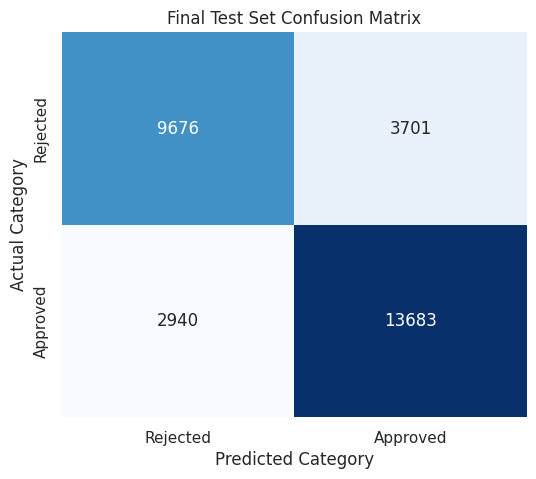

In [21]:
test_preds = prod_model.predict(X_test_full)
test_probs = prod_model.predict_proba(prod_test_pool)[:, 1]

print("=== FINAL MODEL PERFORMANCE REPORT (UNTOUCHED TEST SET) ===\n")
auc_score = roc_auc_score(y_test_full, test_probs)
print(f"ROC-AUC Score: {auc_score:.4f}")
print(classification_report(y_test_full, test_preds))

# Calibration validation via Brier Score Loss (lower is better)
brier = brier_score_loss(y_test_full, test_probs)
print(f"Brier Score Loss (Probability Calibration Quality): {brier:.4f}")

# Plot Confusion Matrix
cm = confusion_matrix(y_test_full, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Rejected', 'Approved'], yticklabels=['Rejected', 'Approved'])
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.title('Final Test Set Confusion Matrix')
plt.show()

### 6. SHAP Explainability & Production Integration
To guarantee "Predict, Explain, Simulate" capabilities in production, we instantiate a SHAP Explainer and run an explanation on a sample applicant.

/tmp/ipykernel_1214/1630517208.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, shap_sample, show=False)


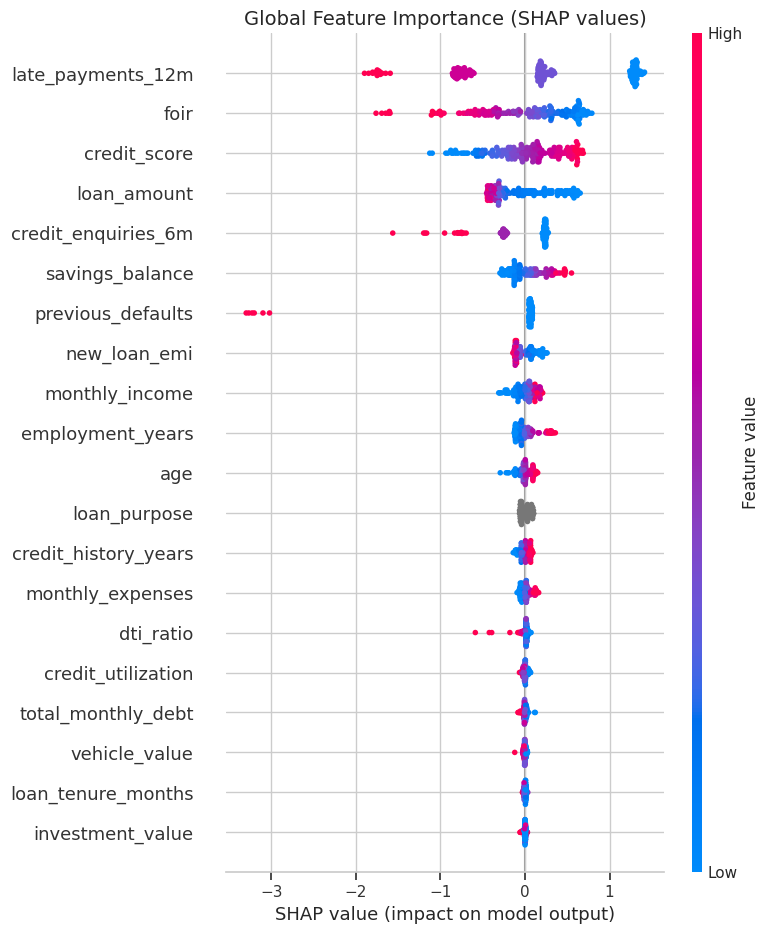

In [22]:
# Calculate SHAP values on a sample of test records
explainer = shap.TreeExplainer(prod_model)
shap_sample = X_test_full.sample(200, random_state=SEED)
shap_values = explainer(shap_sample)

# Plot SHAP summary graph
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, shap_sample, show=False)
plt.title("Global Feature Importance (SHAP values)", fontsize=14)
plt.tight_layout()
plt.show()

=== Applicant ID 76559 Real-time Profile ===
                                 76559
age                                 61
gender                            Male
marital_status                 Married
dependents                           4
education                     Graduate
employment_type               Salaried
employment_years                     9
city_tier                       Tier 1
monthly_income           149838.665445
coapplicant_income        11910.407076
other_monthly_income               0.0
existing_loan_count                  1
existing_emi              12745.595455
credit_card_outstanding   35955.575325
monthly_expenses          46342.274761
total_outstanding_debt    293146.69039
credit_score                       753
credit_history_years                38
active_credit_accounts               3
late_payments_12m                    0
previous_defaults                    0
credit_enquiries_6m                  1
credit_utilization            0.023298
savings_balance    

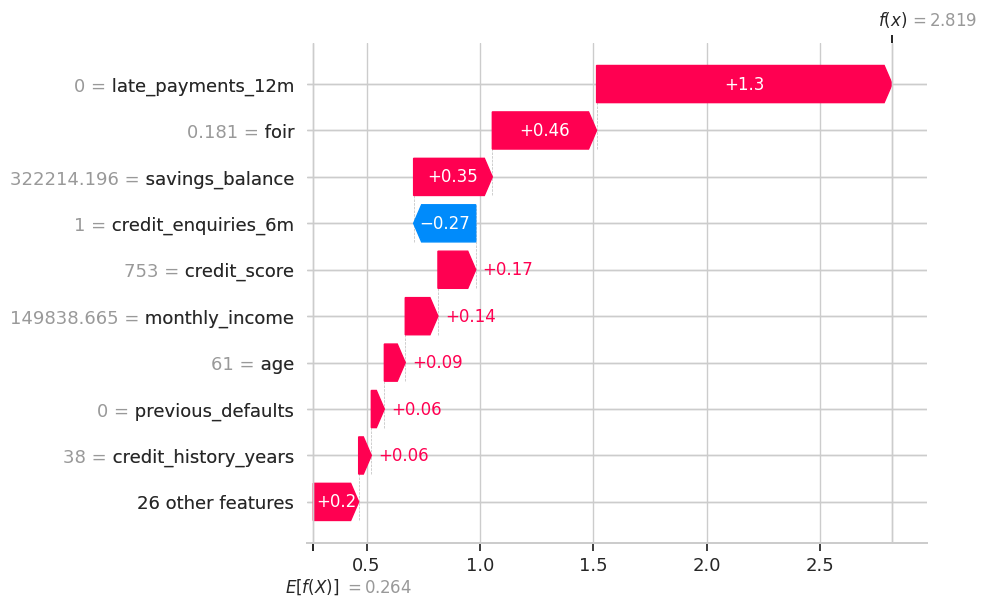

In [23]:
# Single Applicant Prediction & Explainability Simulation
applicant_idx = X_test_full.index[0]
sample_applicant = X_test_full.loc[[applicant_idx]]
real_class = y_test_full.loc[applicant_idx]

pred_prob = prod_model.predict_proba(sample_applicant)[0][1]
pred_class = prod_model.predict(sample_applicant)[0]

print(f"=== Applicant ID {applicant_idx} Real-time Profile ===")
print(sample_applicant.T)
print(f"\nActual Decision: {'Approved' if real_class == 1 else 'Rejected'}")
print(f"Model Prediction: {'Approved' if pred_class == 1 else 'Rejected'} (Probability: {pred_prob:.2%})")

# Individual SHAP Waterfall Explanation
applicant_shap_values = explainer(sample_applicant)
plt.figure(figsize=(8, 4))
shap.plots.waterfall(applicant_shap_values[0])
plt.show()

### 4. Generation and Evaluation of Final 150,000 Dataset
With the prototype validated, we now generate the final large dataset of 150,000 samples under the exact same seed (`42`) and configuration, split the data, and fit our production CatBoost model.

In [24]:
# 1. Generate full 150k dataset
df_150k = generate_loan_dataset(150000, seed=SEED)
print(f"Final 150k Dataset generated. Shape: {df_150k.shape}")

# 2. Run validations on 150k dataset
run_dataset_validation(df_150k)

# 3. Save datasets to Disk
df_10k_cleaned = df_10k.drop(columns=[col for col in features_to_exclude if col in df_10k.columns and col != 'loan_approved'])
df_150k_cleaned = df_150k.drop(columns=[col for col in features_to_exclude if col in df_150k.columns and col != 'loan_approved'])

df_10k_cleaned.to_csv('synthetic_loan_data_10k.csv', index=False)
df_150k_cleaned.to_csv('synthetic_loan_data_150k.csv', index=False)
print("Saved cleanses of 'synthetic_loan_data_10k.csv' and 'synthetic_loan_data_150k.csv' to workspace.")

Final 150k Dataset generated. Shape: (150000, 36)
=== DATASET VALIDATION REPORT ===

Total Rows: 150000
Missing Values:
0 missing values found.
Duplicate Rows: 0

Logical Consistency Violations:
- Invalid Age (outside 21-70): 0
- Invalid Credit Score (outside 300-900): 0
- EMI greater than Total Monthly Debt: 0
- Negative FOIR: 0

Key Feature Distributions Summary:
                   count          mean           std          min  \
monthly_income  150000.0  9.699336e+04  6.381111e+04  15000.00000   
credit_score    150000.0  7.083846e+02  9.737159e+01    308.00000   
loan_amount     150000.0  1.631951e+06  1.835692e+06  50000.00000   
foir            150000.0  4.055589e-01  4.114748e-01      0.00317   

                          25%            50%           75%           max  
monthly_income   54125.870429   81176.563660  1.212724e+05  1.018881e+06  
credit_score       642.000000     710.000000  7.770000e+02  9.000000e+02  
loan_amount     376576.848258  875090.198618  2.338779e+06  2

In [25]:
# 4. Split 150k dataset for final production training
X_full = df_150k_cleaned.drop(columns=['loan_approved'])
y_full = df_150k_cleaned['loan_approved']

X_temp_full, X_test_full, y_temp_full, y_test_full = train_test_split(X_full, y_full, test_size=0.20, random_state=SEED, stratify=y_full)
X_train_full, X_val_full, y_train_full, y_val_full = train_test_split(X_temp_full, y_temp_full, test_size=0.20, random_state=SEED, stratify=y_temp_full)

# Fit production model
prod_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.04,
    depth=6,
    eval_metric='AUC',
    random_seed=SEED,
    verbose=200
)

prod_train_pool = Pool(X_train_full, y_train_full, cat_features=cat_features)
prod_val_pool = Pool(X_val_full, y_val_full, cat_features=cat_features)
prod_test_pool = Pool(X_test_full, cat_features=cat_features)

prod_model.fit(prod_train_pool, eval_set=prod_val_pool, early_stopping_rounds=50, use_best_model=True)

# Save model to disk
prod_model.save_model('know_your_loan_catboost_model.cbm')
print("Production model 'know_your_loan_catboost_model.cbm' successfully trained and saved.")

0:	test: 0.8152027	best: 0.8152027 (0)	total: 197ms	remaining: 3m 16s
200:	test: 0.8581116	best: 0.8581116 (199)	total: 37s	remaining: 2m 27s
400:	test: 0.8583681	best: 0.8583865 (377)	total: 1m 10s	remaining: 1m 45s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8583864946
bestIteration = 377

Shrink model to first 378 iterations.
Production model 'know_your_loan_catboost_model.cbm' successfully trained and saved.


### 5. Final Evaluation Report on Untouched Test Set
We compute key classification metrics, probability calibration metrics, and build the confusion matrix on our untouched test set.

=== FINAL MODEL PERFORMANCE REPORT (UNTOUCHED TEST SET) ===

ROC-AUC Score: 0.8604
              precision    recall  f1-score   support

           0       0.77      0.72      0.74     13377
           1       0.79      0.82      0.80     16623

    accuracy                           0.78     30000
   macro avg       0.78      0.77      0.77     30000
weighted avg       0.78      0.78      0.78     30000

Brier Score Loss (Probability Calibration Quality): 0.1506


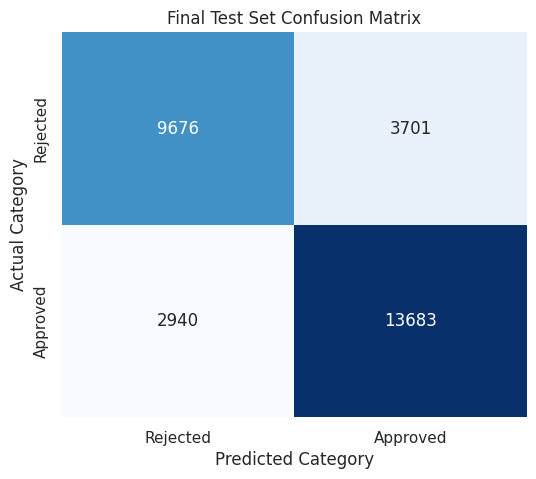

In [26]:
test_preds = prod_model.predict(X_test_full)
test_probs = prod_model.predict_proba(prod_test_pool)[:, 1]

print("=== FINAL MODEL PERFORMANCE REPORT (UNTOUCHED TEST SET) ===\n")
auc_score = roc_auc_score(y_test_full, test_probs)
print(f"ROC-AUC Score: {auc_score:.4f}")
print(classification_report(y_test_full, test_preds))

# Calibration validation via Brier Score Loss (lower is better)
brier = brier_score_loss(y_test_full, test_probs)
print(f"Brier Score Loss (Probability Calibration Quality): {brier:.4f}")

# Plot Confusion Matrix
cm = confusion_matrix(y_test_full, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Rejected', 'Approved'], yticklabels=['Rejected', 'Approved'])
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.title('Final Test Set Confusion Matrix')
plt.show()

### 6. SHAP Explainability & Production Integration
To guarantee "Predict, Explain, Simulate" capabilities in production, we instantiate a SHAP Explainer and run an explanation on a sample applicant.

/tmp/ipykernel_1214/1630517208.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, shap_sample, show=False)


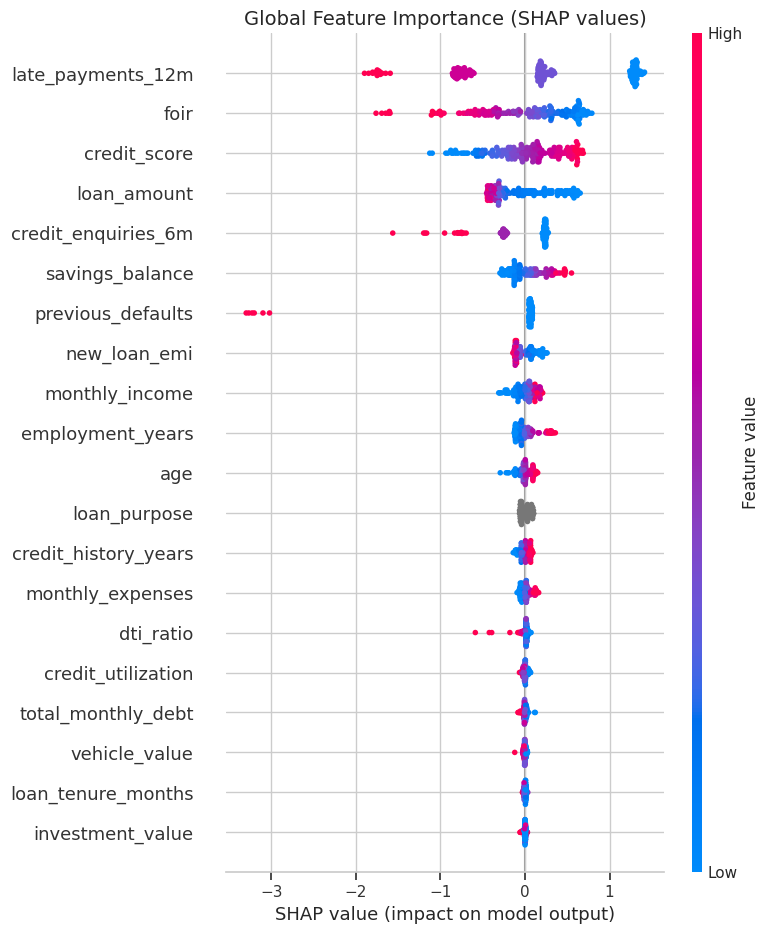

In [27]:
# Calculate SHAP values on a sample of test records
explainer = shap.TreeExplainer(prod_model)
shap_sample = X_test_full.sample(200, random_state=SEED)
shap_values = explainer(shap_sample)

# Plot SHAP summary graph
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, shap_sample, show=False)
plt.title("Global Feature Importance (SHAP values)", fontsize=14)
plt.tight_layout()
plt.show()

=== Applicant ID 76559 Real-time Profile ===
                                 76559
age                                 61
gender                            Male
marital_status                 Married
dependents                           4
education                     Graduate
employment_type               Salaried
employment_years                     9
city_tier                       Tier 1
monthly_income           149838.665445
coapplicant_income        11910.407076
other_monthly_income               0.0
existing_loan_count                  1
existing_emi              12745.595455
credit_card_outstanding   35955.575325
monthly_expenses          46342.274761
total_outstanding_debt    293146.69039
credit_score                       753
credit_history_years                38
active_credit_accounts               3
late_payments_12m                    0
previous_defaults                    0
credit_enquiries_6m                  1
credit_utilization            0.023298
savings_balance    

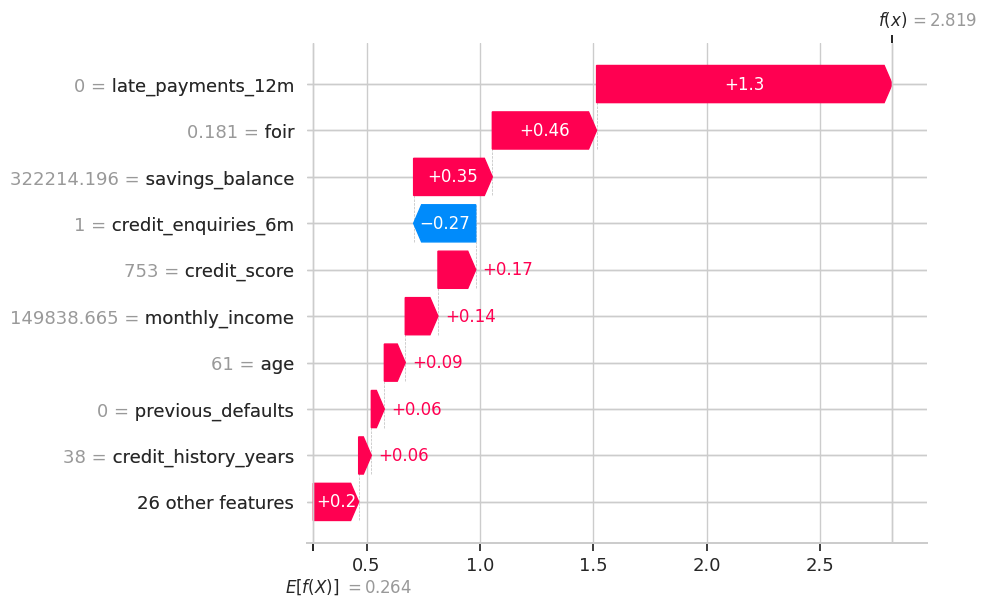

In [28]:
# Single Applicant Prediction & Explainability Simulation
applicant_idx = X_test_full.index[0]
sample_applicant = X_test_full.loc[[applicant_idx]]
real_class = y_test_full.loc[applicant_idx]

pred_prob = prod_model.predict_proba(sample_applicant)[0][1]
pred_class = prod_model.predict(sample_applicant)[0]

print(f"=== Applicant ID {applicant_idx} Real-time Profile ===")
print(sample_applicant.T)
print(f"\nActual Decision: {'Approved' if real_class == 1 else 'Rejected'}")
print(f"Model Prediction: {'Approved' if pred_class == 1 else 'Rejected'} (Probability: {pred_prob:.2%})")

# Individual SHAP Waterfall Explanation
applicant_shap_values = explainer(sample_applicant)
plt.figure(figsize=(8, 4))
shap.plots.waterfall(applicant_shap_values[0])
plt.show()

### 7. Decision Threshold Optimization for F1-Score Enhancement
We optimize the classification threshold on the **validation partition probabilities** to maximize the F1-score for Class 1 (Approved Loans). This avoids test-set leakage while ensuring our final predictions are well-tuned for balanced performance.

In [34]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, classification_report, confusion_matrix, roc_auc_score

# 1. Obtain probabilities on the validation partition
val_probs = prod_model.predict_proba(prod_val_pool)[:, 1]
y_val_true = y_val_full.values

# 2. Iterate thresholds from 0.20 to 0.80 in steps of 0.01
thresholds = np.arange(0.20, 0.81, 0.01)
best_threshold = 0.50
best_val_f1 = 0.0

f1_at_05 = 0.0

results = {}
for t in thresholds:
    preds_t = (val_probs >= t).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(y_val_true, preds_t, average='binary', pos_label=1)
    results[t] = {'precision': precision, 'recall': recall, 'f1': f1}

    if abs(t - 0.50) < 0.001:
        f1_at_05 = f1

    if f1 > best_val_f1:
        best_val_f1 = f1
        best_threshold = t

print("=== VALIDATION THRESHOLD TUNING ===")
print(f"F1-Score at Default (0.50) Threshold: {f1_at_05:.4f}")
print(f"Best Validation Threshold: {best_threshold:.2f}")
print(f"Best Validation F1-Score: {best_val_f1:.4f}")
print(f"Precision at Best Threshold: {results[best_threshold]['precision']:.4f}")
print(f"Recall at Best Threshold: {results[best_threshold]['recall']:.4f}")

=== VALIDATION THRESHOLD TUNING ===
F1-Score at Default (0.50) Threshold: 0.8058
Best Validation Threshold: 0.45
Best Validation F1-Score: 0.8099
Precision at Best Threshold: 0.7648
Recall at Best Threshold: 0.8607


Now, we apply this optimized decision threshold to our completely untouched test-set partition probabilities (`test_probs`) and compare the performance characteristics.

In [35]:
# 3. Evaluate on Untouched Test Set
y_test_true = y_test_full.values

# Default threshold baseline
test_preds_050 = (test_probs >= 0.50).astype(int)
_, _, test_f1_050, _ = precision_recall_fscore_support(y_test_true, test_preds_050, average='binary', pos_label=1)

# Optimized threshold predictions
test_preds_opt = (test_probs >= best_threshold).astype(int)
opt_precision, opt_recall, opt_f1, _ = precision_recall_fscore_support(y_test_true, test_preds_opt, average='binary', pos_label=1)
opt_accuracy = accuracy_score(y_test_true, test_preds_opt)
opt_roc_auc = roc_auc_score(y_test_true, test_probs)

print("=== UNTOUCHED TEST SET FINAL EVALUATION ===")
print(f"Previous Test F1-Score (at 0.50): {test_f1_050:.4f}")
print(f"Optimized Test F1-Score (at {best_threshold:.2f}): {opt_f1:.4f}")
print(f"Change in F1-Score: {opt_f1 - test_f1_050:+.4f}\n")

print(f"FINAL THRESHOLD: {best_threshold:.2f}")
print(f"FINAL TEST ACCURACY: {opt_accuracy:.4f}")
print(f"FINAL TEST PRECISION: {opt_precision:.4f}")
print(f"FINAL TEST RECALL: {opt_recall:.4f}")
print(f"FINAL TEST F1: {opt_f1:.4f}")
print(f"FINAL TEST ROC-AUC: {opt_roc_auc:.4f}\n")

# Display new confusion matrix
print("Optimized Test Confusion Matrix:")
print(confusion_matrix(y_test_true, test_preds_opt))

=== UNTOUCHED TEST SET FINAL EVALUATION ===
Previous Test F1-Score (at 0.50): 0.8047
Optimized Test F1-Score (at 0.45): 0.8097
Change in F1-Score: +0.0050

FINAL THRESHOLD: 0.45
FINAL TEST ACCURACY: 0.7766
FINAL TEST PRECISION: 0.7666
FINAL TEST RECALL: 0.8580
FINAL TEST F1: 0.8097
FINAL TEST ROC-AUC: 0.8604

Optimized Test Confusion Matrix:
[[ 9035  4342]
 [ 2361 14262]]


### 2. Dataset Quality and Realism Validation
We now perform senior-level checks on the prototype dataset:
1. Check for missing values and duplicates
2. Run financial and logical consistency checks
3. Check extreme but logical values (outliers)
4. Verify specific sample underwriting rules (e.g. Credit Score and FOIR interactions)

In [9]:
def run_dataset_validation(df):
    print("=== DATASET VALIDATION REPORT ===\n")
    print(f"Total Rows: {len(df)}")
    print(f"Missing Values:\n{df.isnull().sum().sum()} missing values found.")
    print(f"Duplicate Rows: {df.duplicated().sum()}")

    # Range and impossible logical value checks
    age_invalid = ((df['age'] < 21) | (df['age'] > 70)).sum()
    cibil_invalid = ((df['credit_score'] < 300) | (df['credit_score'] > 900)).sum()
    emi_vs_debt = (df['new_loan_emi'] > df['total_monthly_debt']).sum()
    foir_negative = (df['foir'] < 0).sum()

    print(f"\nLogical Consistency Violations:")
    print(f"- Invalid Age (outside 21-70): {age_invalid}")
    print(f"- Invalid Credit Score (outside 300-900): {cibil_invalid}")
    print(f"- EMI greater than Total Monthly Debt: {emi_vs_debt}")
    print(f"- Negative FOIR: {foir_negative}")

    print("\nKey Feature Distributions Summary:")
    print(df[['monthly_income', 'credit_score', 'loan_amount', 'foir']].describe().T)

    # Realism Checks
    high_credit_low_foir = df[(df['credit_score'] >= 750) & (df['foir'] <= 0.35)]
    low_credit_high_foir = df[(df['credit_score'] <= 500) & (df['foir'] >= 0.70)]

    print(f"\nRealism Scenarios (Signal Quality Check):")
    print(f"- High Credit (>=750) & Low FOIR (<=35%) Approval Rate: {high_credit_low_foir['loan_approved'].mean():.2%}")
    print(f"- Low Credit (<=500) & High FOIR (>=70%) Approval Rate: {low_credit_high_foir['loan_approved'].mean():.2%}")

run_dataset_validation(df_10k)

=== DATASET VALIDATION REPORT ===

Total Rows: 10000
Missing Values:
0 missing values found.
Duplicate Rows: 0

Logical Consistency Violations:
- Invalid Age (outside 21-70): 0
- Invalid Credit Score (outside 300-900): 0
- EMI greater than Total Monthly Debt: 0
- Negative FOIR: 0

Key Feature Distributions Summary:
                  count          mean           std           min  \
monthly_income  10000.0  9.715753e+04  6.332317e+04  15000.000000   
credit_score    10000.0  7.097660e+02  9.699469e+01    330.000000   
loan_amount     10000.0  1.637128e+06  1.816451e+06  50000.000000   
foir            10000.0  4.002027e-01  3.945151e-01      0.007124   

                          25%            50%           75%           max  
monthly_income   54084.392286   81792.537563  1.214366e+05  6.744338e+05  
credit_score       643.000000     712.000000  7.780000e+02  9.000000e+02  
loan_amount     378942.152977  875862.731308  2.378220e+06  1.802793e+07  
foir                 0.154596       0

### 3. Model Training, Selection & Baseline Evaluation
We split the dataset into Train (64%), Validation (16%), and Test (20%) sets.

**CRITICAL PREVENT LEAKAGE STEP**: We ensure all intermediate latent factors (`latent_score`, `approval_probability`, etc.) do not exist in the final training dataset. We will train Logistic Regression, Random Forest, and CatBoost. CatBoost natively processes categorical features without manual encoding, making it ideal for our website's production environment.

In [10]:
# Feature list
features_to_exclude = ['loan_approved', 'latent_score', 'approval_probability', 'credit_strength', 'affordability_strength', 'employment_strength', 'financial_stability', 'loan_burden']

# Identify categorical and numeric columns
cat_features = ['gender', 'marital_status', 'education', 'employment_type', 'city_tier', 'loan_purpose']
num_features = [col for col in df_10k.columns if col not in cat_features + ['loan_approved']]

# Prepare X and y
X = df_10k.drop(columns=[col for col in features_to_exclude if col in df_10k.columns])
y = df_10k['loan_approved']

# Split: 64% Train, 16% Val, 20% Test (utilizing stratified splits to preserve balance)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.20, random_state=SEED, stratify=y_temp)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Features included: {list(X.columns)}")

Training set shape: (6400, 35)
Validation set shape: (1600, 35)
Test set shape: (2000, 35)
Features included: ['age', 'gender', 'marital_status', 'dependents', 'education', 'employment_type', 'employment_years', 'city_tier', 'monthly_income', 'coapplicant_income', 'other_monthly_income', 'existing_loan_count', 'existing_emi', 'credit_card_outstanding', 'monthly_expenses', 'total_outstanding_debt', 'credit_score', 'credit_history_years', 'active_credit_accounts', 'late_payments_12m', 'previous_defaults', 'credit_enquiries_6m', 'credit_utilization', 'savings_balance', 'property_value', 'vehicle_value', 'investment_value', 'loan_amount', 'loan_tenure_months', 'loan_purpose', 'annual_interest_rate', 'new_loan_emi', 'total_monthly_debt', 'dti_ratio', 'foir']


In [11]:
# Model 1: Logistic Regression (as a baseline; utilizing one-hot encoding on categorical values)
X_train_encoded = pd.get_dummies(X_train, columns=cat_features, drop_first=True)
X_val_encoded = pd.get_dummies(X_val, columns=cat_features, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=cat_features, drop_first=True)

# Align columns
X_val_encoded = X_val_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_val_scaled = scaler.transform(X_val_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

lr_model = LogisticRegression(max_iter=1000, random_state=SEED)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_val_scaled)
lr_probs = lr_model.predict_proba(X_val_scaled)[:, 1]

print("=== Logistic Regression Baseline (Validation Set) ===")
print(f"ROC-AUC: {roc_auc_score(y_val, lr_probs):.4f}")
print(classification_report(y_val, lr_preds))

=== Logistic Regression Baseline (Validation Set) ===
ROC-AUC: 0.8482
              precision    recall  f1-score   support

           0       0.75      0.73      0.74       722
           1       0.78      0.80      0.79       878

    accuracy                           0.77      1600
   macro avg       0.76      0.76      0.76      1600
weighted avg       0.77      0.77      0.77      1600



In [12]:
# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_model.fit(X_train_encoded, y_train)
rf_preds = rf_model.predict(X_val_encoded)
rf_probs = rf_model.predict_proba(X_val_encoded)[:, 1]

print("=== Random Forest (Validation Set) ===")
print(f"ROC-AUC: {roc_auc_score(y_val, rf_probs):.4f}")
print(classification_report(y_val, rf_preds))

=== Random Forest (Validation Set) ===
ROC-AUC: 0.8408
              precision    recall  f1-score   support

           0       0.74      0.73      0.74       722
           1       0.78      0.79      0.79       878

    accuracy                           0.76      1600
   macro avg       0.76      0.76      0.76      1600
weighted avg       0.76      0.76      0.76      1600



In [13]:
# Model 3: CatBoost Classifier (Native Categorical Handling)
cb_model = CatBoostClassifier(
    iterations=600,
    learning_rate=0.04,
    depth=6,
    eval_metric='AUC',
    random_seed=SEED,
    verbose=100
)

train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)

cb_model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=50, use_best_model=True)

cb_preds = cb_model.predict(X_val)
cb_probs = cb_model.predict_proba(X_val)[:, 1]

print("\n=== CatBoost Classifier (Validation Set) ===")
print(f"ROC-AUC: {roc_auc_score(y_val, cb_probs):.4f}")
print(classification_report(y_val, cb_preds))

0:	test: 0.8075250	best: 0.8075250 (0)	total: 22ms	remaining: 13.2s
100:	test: 0.8533670	best: 0.8538734 (92)	total: 1.85s	remaining: 9.13s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8538733839
bestIteration = 92

Shrink model to first 93 iterations.

=== CatBoost Classifier (Validation Set) ===
ROC-AUC: 0.8539
              precision    recall  f1-score   support

           0       0.76      0.73      0.74       722
           1       0.78      0.81      0.80       878

    accuracy                           0.77      1600
   macro avg       0.77      0.77      0.77      1600
weighted avg       0.77      0.77      0.77      1600



### 2. Dataset Quality and Realism Validation
We now perform senior-level checks on the prototype dataset:
1. Check for missing values and duplicates
2. Run financial and logical consistency checks
3. Check extreme but logical values (outliers)
4. Verify specific sample underwriting rules (e.g. Credit Score and FOIR interactions)

In [14]:
def run_dataset_validation(df):
    print("=== DATASET VALIDATION REPORT ===\n")
    print(f"Total Rows: {len(df)}")
    print(f"Missing Values:\n{df.isnull().sum().sum()} missing values found.")
    print(f"Duplicate Rows: {df.duplicated().sum()}")

    # Range and impossible logical value checks
    age_invalid = ((df['age'] < 21) | (df['age'] > 70)).sum()
    cibil_invalid = ((df['credit_score'] < 300) | (df['credit_score'] > 900)).sum()
    emi_vs_debt = (df['new_loan_emi'] > df['total_monthly_debt']).sum()
    foir_negative = (df['foir'] < 0).sum()

    print(f"\nLogical Consistency Violations:")
    print(f"- Invalid Age (outside 21-70): {age_invalid}")
    print(f"- Invalid Credit Score (outside 300-900): {cibil_invalid}")
    print(f"- EMI greater than Total Monthly Debt: {emi_vs_debt}")
    print(f"- Negative FOIR: {foir_negative}")

    print("\nKey Feature Distributions Summary:")
    print(df[['monthly_income', 'credit_score', 'loan_amount', 'foir']].describe().T)

    # Realism Checks
    high_credit_low_foir = df[(df['credit_score'] >= 750) & (df['foir'] <= 0.35)]
    low_credit_high_foir = df[(df['credit_score'] <= 500) & (df['foir'] >= 0.70)]

    print(f"\nRealism Scenarios (Signal Quality Check):")
    print(f"- High Credit (>=750) & Low FOIR (<=35%) Approval Rate: {high_credit_low_foir['loan_approved'].mean():.2%}")
    print(f"- Low Credit (<=500) & High FOIR (>=70%) Approval Rate: {low_credit_high_foir['loan_approved'].mean():.2%}")

run_dataset_validation(df_10k)

=== DATASET VALIDATION REPORT ===

Total Rows: 10000
Missing Values:
0 missing values found.
Duplicate Rows: 0

Logical Consistency Violations:
- Invalid Age (outside 21-70): 0
- Invalid Credit Score (outside 300-900): 0
- EMI greater than Total Monthly Debt: 0
- Negative FOIR: 0

Key Feature Distributions Summary:
                  count          mean           std           min  \
monthly_income  10000.0  9.715753e+04  6.332317e+04  15000.000000   
credit_score    10000.0  7.097660e+02  9.699469e+01    330.000000   
loan_amount     10000.0  1.637128e+06  1.816451e+06  50000.000000   
foir            10000.0  4.002027e-01  3.945151e-01      0.007124   

                          25%            50%           75%           max  
monthly_income   54084.392286   81792.537563  1.214366e+05  6.744338e+05  
credit_score       643.000000     712.000000  7.780000e+02  9.000000e+02  
loan_amount     378942.152977  875862.731308  2.378220e+06  1.802793e+07  
foir                 0.154596       0

### 3. Model Training, Selection & Baseline Evaluation
We split the dataset into Train (64%), Validation (16%), and Test (20%) sets.

**CRITICAL PREVENT LEAKAGE STEP**: We ensure all intermediate latent factors (`latent_score`, `approval_probability`, etc.) do not exist in the final training dataset. We will train Logistic Regression, Random Forest, and CatBoost. CatBoost natively processes categorical features without manual encoding, making it ideal for our website's production environment.

In [15]:
# Feature list
features_to_exclude = ['loan_approved', 'latent_score', 'approval_probability', 'credit_strength', 'affordability_strength', 'employment_strength', 'financial_stability', 'loan_burden']

# Identify categorical and numeric columns
cat_features = ['gender', 'marital_status', 'education', 'employment_type', 'city_tier', 'loan_purpose']
num_features = [col for col in df_10k.columns if col not in cat_features + ['loan_approved']]

# Prepare X and y
X = df_10k.drop(columns=[col for col in features_to_exclude if col in df_10k.columns])
y = df_10k['loan_approved']

# Split: 64% Train, 16% Val, 20% Test (utilizing stratified splits to preserve balance)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.20, random_state=SEED, stratify=y_temp)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Features included: {list(X.columns)}")

Training set shape: (6400, 35)
Validation set shape: (1600, 35)
Test set shape: (2000, 35)
Features included: ['age', 'gender', 'marital_status', 'dependents', 'education', 'employment_type', 'employment_years', 'city_tier', 'monthly_income', 'coapplicant_income', 'other_monthly_income', 'existing_loan_count', 'existing_emi', 'credit_card_outstanding', 'monthly_expenses', 'total_outstanding_debt', 'credit_score', 'credit_history_years', 'active_credit_accounts', 'late_payments_12m', 'previous_defaults', 'credit_enquiries_6m', 'credit_utilization', 'savings_balance', 'property_value', 'vehicle_value', 'investment_value', 'loan_amount', 'loan_tenure_months', 'loan_purpose', 'annual_interest_rate', 'new_loan_emi', 'total_monthly_debt', 'dti_ratio', 'foir']


In [16]:
# Model 1: Logistic Regression (as a baseline; utilizing one-hot encoding on categorical values)
X_train_encoded = pd.get_dummies(X_train, columns=cat_features, drop_first=True)
X_val_encoded = pd.get_dummies(X_val, columns=cat_features, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=cat_features, drop_first=True)

# Align columns
X_val_encoded = X_val_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_val_scaled = scaler.transform(X_val_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

lr_model = LogisticRegression(max_iter=1000, random_state=SEED)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_val_scaled)
lr_probs = lr_model.predict_proba(X_val_scaled)[:, 1]

print("=== Logistic Regression Baseline (Validation Set) ===")
print(f"ROC-AUC: {roc_auc_score(y_val, lr_probs):.4f}")
print(classification_report(y_val, lr_preds))

=== Logistic Regression Baseline (Validation Set) ===
ROC-AUC: 0.8482
              precision    recall  f1-score   support

           0       0.75      0.73      0.74       722
           1       0.78      0.80      0.79       878

    accuracy                           0.77      1600
   macro avg       0.76      0.76      0.76      1600
weighted avg       0.77      0.77      0.77      1600



In [17]:
# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_model.fit(X_train_encoded, y_train)
rf_preds = rf_model.predict(X_val_encoded)
rf_probs = rf_model.predict_proba(X_val_encoded)[:, 1]

print("=== Random Forest (Validation Set) ===")
print(f"ROC-AUC: {roc_auc_score(y_val, rf_probs):.4f}")
print(classification_report(y_val, rf_preds))

=== Random Forest (Validation Set) ===
ROC-AUC: 0.8408
              precision    recall  f1-score   support

           0       0.74      0.73      0.74       722
           1       0.78      0.79      0.79       878

    accuracy                           0.76      1600
   macro avg       0.76      0.76      0.76      1600
weighted avg       0.76      0.76      0.76      1600



In [18]:
# Model 3: CatBoost Classifier (Native Categorical Handling)
cb_model = CatBoostClassifier(
    iterations=600,
    learning_rate=0.04,
    depth=6,
    eval_metric='AUC',
    random_seed=SEED,
    verbose=100
)

train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)

cb_model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=50, use_best_model=True)

cb_preds = cb_model.predict(X_val)
cb_probs = cb_model.predict_proba(X_val)[:, 1]

print("\n=== CatBoost Classifier (Validation Set) ===")
print(f"ROC-AUC: {roc_auc_score(y_val, cb_probs):.4f}")
print(classification_report(y_val, cb_preds))

0:	test: 0.8075250	best: 0.8075250 (0)	total: 21.9ms	remaining: 13.1s
100:	test: 0.8533670	best: 0.8538734 (92)	total: 1.89s	remaining: 9.34s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8538733839
bestIteration = 92

Shrink model to first 93 iterations.

=== CatBoost Classifier (Validation Set) ===
ROC-AUC: 0.8539
              precision    recall  f1-score   support

           0       0.76      0.73      0.74       722
           1       0.78      0.81      0.80       878

    accuracy                           0.77      1600
   macro avg       0.77      0.77      0.77      1600
weighted avg       0.77      0.77      0.77      1600



### 4. Generation and Evaluation of Final 150,000 Dataset
With the prototype validated, we now generate the final large dataset of 150,000 samples under the exact same seed (`42`) and configuration, split the data, and fit our production CatBoost model.

In [29]:
# 1. Generate full 150k dataset
df_150k = generate_loan_dataset(150000, seed=SEED)
print(f"Final 150k Dataset generated. Shape: {df_150k.shape}")

# 2. Run validations on 150k dataset
run_dataset_validation(df_150k)

# 3. Save datasets to Disk
features_to_exclude = ['latent_score', 'approval_probability', 'credit_strength', 'affordability_strength', 'employment_strength', 'financial_stability', 'loan_burden']
df_10k_cleaned = df_10k.drop(columns=[col for col in features_to_exclude if col in df_10k.columns])
df_150k_cleaned = df_150k.drop(columns=[col for col in features_to_exclude if col in df_150k.columns])

df_10k_cleaned.to_csv('synthetic_loan_data_10k.csv', index=False)
df_150k_cleaned.to_csv('synthetic_loan_data_150k.csv', index=False)
print("Saved cleanses of 'synthetic_loan_data_10k.csv' and 'synthetic_loan_data_150k.csv' to workspace.")

Final 150k Dataset generated. Shape: (150000, 36)
=== DATASET VALIDATION REPORT ===

Total Rows: 150000
Missing Values:
0 missing values found.
Duplicate Rows: 0

Logical Consistency Violations:
- Invalid Age (outside 21-70): 0
- Invalid Credit Score (outside 300-900): 0
- EMI greater than Total Monthly Debt: 0
- Negative FOIR: 0

Key Feature Distributions Summary:
                   count          mean           std          min  \
monthly_income  150000.0  9.699336e+04  6.381111e+04  15000.00000   
credit_score    150000.0  7.083846e+02  9.737159e+01    308.00000   
loan_amount     150000.0  1.631951e+06  1.835692e+06  50000.00000   
foir            150000.0  4.055589e-01  4.114748e-01      0.00317   

                          25%            50%           75%           max  
monthly_income   54125.870429   81176.563660  1.212724e+05  1.018881e+06  
credit_score       642.000000     710.000000  7.770000e+02  9.000000e+02  
loan_amount     376576.848258  875090.198618  2.338779e+06  2

In [30]:
# 4. Split 150k dataset for final production training
X_full = df_150k_cleaned.drop(columns=['loan_approved'])
y_full = df_150k_cleaned['loan_approved']

X_temp_full, X_test_full, y_temp_full, y_test_full = train_test_split(X_full, y_full, test_size=0.20, random_state=SEED, stratify=y_full)
X_train_full, X_val_full, y_train_full, y_val_full = train_test_split(X_temp_full, y_temp_full, test_size=0.20, random_state=SEED, stratify=y_temp_full)

# Fit production model
prod_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.04,
    depth=6,
    eval_metric='AUC',
    random_seed=SEED,
    verbose=200
)

prod_train_pool = Pool(X_train_full, y_train_full, cat_features=cat_features)
prod_val_pool = Pool(X_val_full, y_val_full, cat_features=cat_features)
prod_test_pool = Pool(X_test_full, cat_features=cat_features)

prod_model.fit(prod_train_pool, eval_set=prod_val_pool, early_stopping_rounds=50, use_best_model=True)

# Save model to disk
prod_model.save_model('know_your_loan_catboost_model.cbm')
print("Production model 'know_your_loan_catboost_model.cbm' successfully trained and saved.")

0:	test: 0.8152027	best: 0.8152027 (0)	total: 334ms	remaining: 5m 33s
200:	test: 0.8581116	best: 0.8581116 (199)	total: 35s	remaining: 2m 19s
400:	test: 0.8583681	best: 0.8583865 (377)	total: 1m 10s	remaining: 1m 44s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8583864946
bestIteration = 377

Shrink model to first 378 iterations.
Production model 'know_your_loan_catboost_model.cbm' successfully trained and saved.


### 5. Final Evaluation Report on Untouched Test Set
We compute key classification metrics, probability calibration metrics, and build the confusion matrix on our untouched test set.

=== FINAL MODEL PERFORMANCE REPORT (UNTOUCHED TEST SET) ===

ROC-AUC Score: 0.8604
              precision    recall  f1-score   support

           0       0.77      0.72      0.74     13377
           1       0.79      0.82      0.80     16623

    accuracy                           0.78     30000
   macro avg       0.78      0.77      0.77     30000
weighted avg       0.78      0.78      0.78     30000

Brier Score Loss (Probability Calibration Quality): 0.1506


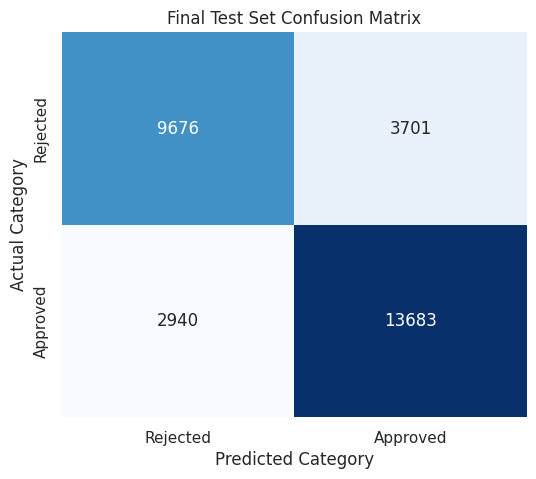

In [31]:
test_preds = prod_model.predict(X_test_full)
test_probs = prod_model.predict_proba(prod_test_pool)[:, 1]

print("=== FINAL MODEL PERFORMANCE REPORT (UNTOUCHED TEST SET) ===\n")
auc_score = roc_auc_score(y_test_full, test_probs)
print(f"ROC-AUC Score: {auc_score:.4f}")
print(classification_report(y_test_full, test_preds))

# Calibration validation via Brier Score Loss (lower is better)
brier = brier_score_loss(y_test_full, test_probs)
print(f"Brier Score Loss (Probability Calibration Quality): {brier:.4f}")

# Plot Confusion Matrix
cm = confusion_matrix(y_test_full, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Rejected', 'Approved'], yticklabels=['Rejected', 'Approved'])
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.title('Final Test Set Confusion Matrix')
plt.show()

### 6. SHAP Explainability & Production Integration
To guarantee 'Predict, Explain, Simulate' capabilities in production, we instantiate a SHAP Explainer and run an explanation on a sample applicant.

/tmp/ipykernel_1214/1630517208.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, shap_sample, show=False)


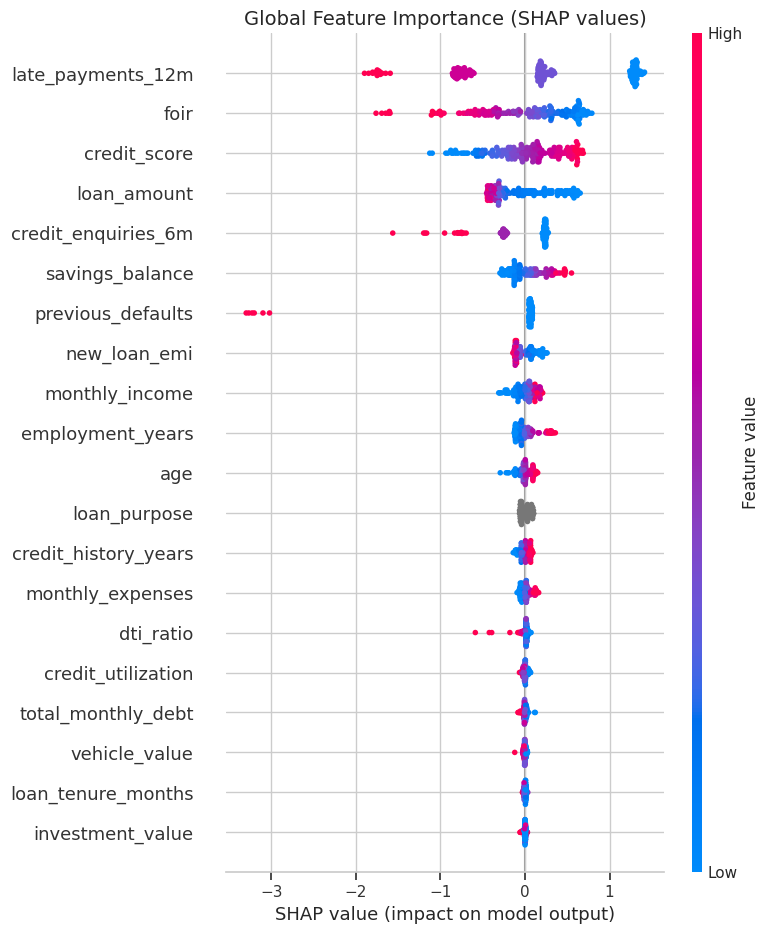

In [32]:
# Calculate SHAP values on a sample of test records
explainer = shap.TreeExplainer(prod_model)
shap_sample = X_test_full.sample(200, random_state=SEED)
shap_values = explainer(shap_sample)

# Plot SHAP summary graph
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, shap_sample, show=False)
plt.title("Global Feature Importance (SHAP values)", fontsize=14)
plt.tight_layout()
plt.show()

=== Applicant ID 76559 Real-time Profile ===
                                 76559
age                                 61
gender                            Male
marital_status                 Married
dependents                           4
education                     Graduate
employment_type               Salaried
employment_years                     9
city_tier                       Tier 1
monthly_income           149838.665445
coapplicant_income        11910.407076
other_monthly_income               0.0
existing_loan_count                  1
existing_emi              12745.595455
credit_card_outstanding   35955.575325
monthly_expenses          46342.274761
total_outstanding_debt    293146.69039
credit_score                       753
credit_history_years                38
active_credit_accounts               3
late_payments_12m                    0
previous_defaults                    0
credit_enquiries_6m                  1
credit_utilization            0.023298
savings_balance    

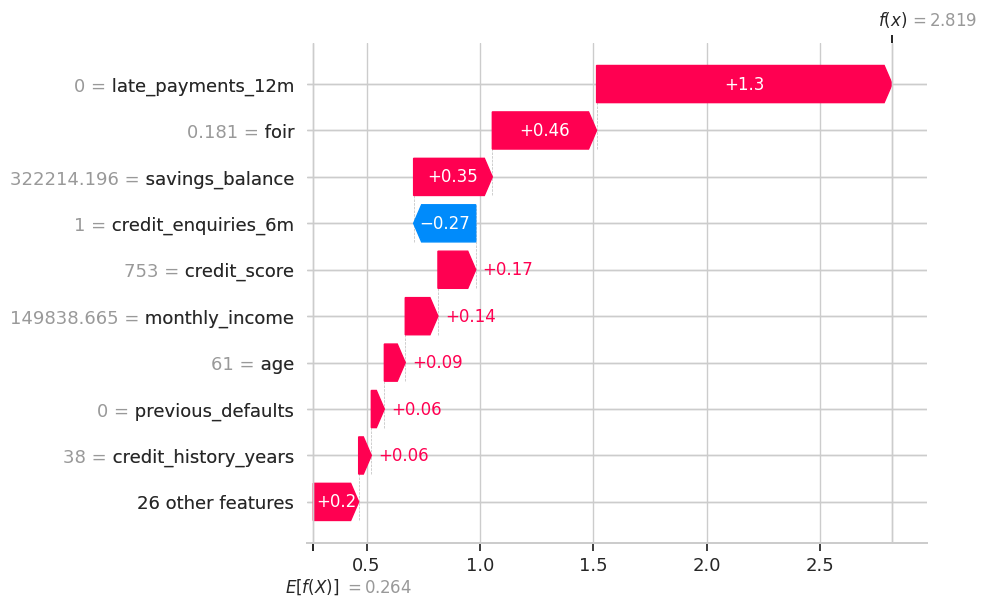

In [33]:
# Single Applicant Prediction & Explainability Simulation
applicant_idx = X_test_full.index[0]
sample_applicant = X_test_full.loc[[applicant_idx]]
real_class = y_test_full.loc[applicant_idx]

pred_prob = prod_model.predict_proba(sample_applicant)[0][1]
pred_class = prod_model.predict(sample_applicant)[0]

print(f"=== Applicant ID {applicant_idx} Real-time Profile ===")
print(sample_applicant.T)
print(f"\nActual Decision: {'Approved' if real_class == 1 else 'Rejected'}")
print(f"Model Prediction: {'Approved' if pred_class == 1 else 'Rejected'} (Probability: {pred_prob:.2%})")

# Individual SHAP Waterfall Explanation
applicant_shap_values = explainer(sample_applicant)
plt.figure(figsize=(8, 4))
shap.plots.waterfall(applicant_shap_values[0])
plt.show()

In [38]:
# ============================================================
# TEST 3 UNSEEN APPLICANTS
# Uses the already-trained final_catboost model
# Threshold = 0.45
# ============================================================
from catboost import CatBoostClassifier

# Load the already-trained final model
final_catboost = CatBoostClassifier()

final_catboost.load_model("know_your_loan_catboost_model.cbm")

print("✅ Final CatBoost model loaded successfully!")
import pandas as pd
import numpy as np

THRESHOLD = 0.45

# ------------------------------------------------------------
# 1. Three completely new applicants
# ------------------------------------------------------------

cases = [

    # CASE 1 — STRONG
    {
        "age": 34,
        "gender": "Male",
        "marital_status": "Married",
        "dependents": 1,
        "education": "Postgraduate",
        "employment_type": "Salaried",
        "employment_years": 9,
        "city_tier": "Tier1",

        "monthly_income": 120000,
        "coapplicant_income": 50000,
        "other_monthly_income": 10000,

        "existing_loans": 1,
        "existing_emi": 8000,
        "credit_card_outstanding": 15000,
        "monthly_expenses": 35000,
        "total_existing_debt": 350000,

        "credit_score": 790,
        "credit_history_years": 11,
        "active_credit_accounts": 4,
        "late_payments": 0,
        "defaults": 0,
        "credit_enquiries_last_6m": 1,
        "credit_utilization": 0.25,

        "savings_balance": 900000,
        "property_value": 7000000,
        "vehicle_value": 900000,
        "investments_value": 1200000,

        "loan_amount": 1500000,
        "loan_tenure_months": 120,
        "loan_purpose": "Home",
        "annual_interest_rate": 8.5
    },

    # CASE 2 — BORDERLINE
    {
        "age": 31,
        "gender": "Male",
        "marital_status": "Married",
        "dependents": 2,
        "education": "Graduate",
        "employment_type": "Salaried",
        "employment_years": 4,
        "city_tier": "Tier2",

        "monthly_income": 65000,
        "coapplicant_income": 20000,
        "other_monthly_income": 0,

        "existing_loans": 2,
        "existing_emi": 12000,
        "credit_card_outstanding": 45000,
        "monthly_expenses": 26000,
        "total_existing_debt": 600000,

        "credit_score": 680,
        "credit_history_years": 7,
        "active_credit_accounts": 5,
        "late_payments": 1,
        "defaults": 0,
        "credit_enquiries_last_6m": 3,
        "credit_utilization": 0.48,

        "savings_balance": 250000,
        "property_value": 3000000,
        "vehicle_value": 500000,
        "investments_value": 200000,

        "loan_amount": 1200000,
        "loan_tenure_months": 84,
        "loan_purpose": "Personal",
        "annual_interest_rate": 13.5
    },

    # CASE 3 — WEAK
    {
        "age": 27,
        "gender": "Male",
        "marital_status": "Single",
        "dependents": 2,
        "education": "Graduate",
        "employment_type": "Contract",
        "employment_years": 2,
        "city_tier": "Tier2",

        "monthly_income": 40000,
        "coapplicant_income": 0,
        "other_monthly_income": 0,

        "existing_loans": 3,
        "existing_emi": 14000,
        "credit_card_outstanding": 70000,
        "monthly_expenses": 22000,
        "total_existing_debt": 800000,

        "credit_score": 520,
        "credit_history_years": 4,
        "active_credit_accounts": 6,
        "late_payments": 4,
        "defaults": 1,
        "credit_enquiries_last_6m": 6,
        "credit_utilization": 0.82,

        "savings_balance": 30000,
        "property_value": 0,
        "vehicle_value": 250000,
        "investments_value": 0,

        "loan_amount": 2000000,
        "loan_tenure_months": 60,
        "loan_purpose": "Personal",
        "annual_interest_rate": 13.5
    }
]

cases_df = pd.DataFrame(cases)

# ------------------------------------------------------------
# 2. Calculate derived financial features
# ------------------------------------------------------------

def calculate_emi(principal, annual_rate, months):
    r = annual_rate / 12 / 100

    if r == 0:
        return principal / months

    return principal * r * (1 + r)**months / ((1 + r)**months - 1)


cases_df["loan_emi"] = cases_df.apply(
    lambda x: calculate_emi(
        x["loan_amount"],
        x["annual_interest_rate"],
        x["loan_tenure_months"]
    ),
    axis=1
)

cases_df["total_monthly_debt"] = (
    cases_df["existing_emi"] +
    cases_df["loan_emi"]
)

cases_df["total_monthly_income"] = (
    cases_df["monthly_income"] +
    cases_df["coapplicant_income"] +
    cases_df["other_monthly_income"]
)

cases_df["dti_ratio"] = (
    cases_df["total_monthly_debt"] /
    cases_df["total_monthly_income"]
)

cases_df["foir"] = (
    cases_df["total_monthly_debt"] /
    (
        cases_df["total_monthly_income"]
        - cases_df["monthly_expenses"] * 0.5
    )
)

# ------------------------------------------------------------
# 3. Make categorical columns strings
# ------------------------------------------------------------

categorical_cols = [
    "gender",
    "marital_status",
    "education",
    "employment_type",
    "city_tier",
    "loan_purpose"
]

for col in categorical_cols:
    cases_df[col] = cases_df[col].astype(str)

# ------------------------------------------------------------
# 4. Prediction
# ------------------------------------------------------------

# Remove anything that is not a model feature if necessary
X_cases = cases_df.copy()

probabilities = final_catboost.predict_proba(X_cases)[:, 1]

predictions = (probabilities >= THRESHOLD).astype(int)

# ------------------------------------------------------------
# 5. Display results
# ------------------------------------------------------------

results = pd.DataFrame({
    "Case": ["Strong", "Borderline", "Weak"],
    "Credit Score": cases_df["credit_score"],
    "Monthly Income": cases_df["monthly_income"],
    "Loan Amount": cases_df["loan_amount"],
    "FOIR": cases_df["foir"],
    "Approval Probability": probabilities,
    "Threshold": THRESHOLD,
    "Prediction": np.where(
        predictions == 1,
        "APPROVED",
        "REJECTED"
    )
})

results["FOIR"] = results["FOIR"].round(3)
results["Approval Probability"] = (
    results["Approval Probability"] * 100
).round(2)

display(results)

✅ Final CatBoost model loaded successfully!


CatBoostError: catboost/libs/data/model_dataset_compatibility.cpp:81: At position 11 should be feature with name existing_loan_count (found existing_loans).

In [41]:
# EXACT feature schema of the saved CatBoost model

feature_names = final_catboost.feature_names_

print("Number of features:", len(feature_names))
print("\nEXACT MODEL FEATURES:\n")

for i, feature in enumerate(feature_names):
    print(f"{i:2d} → {feature}")

print("\n\nCATEGORICAL FEATURES:\n")

cat_indices = final_catboost.get_cat_feature_indices()

for i in cat_indices:
    print(f"{i:2d} → {feature_names[i]}")

Number of features: 35

EXACT MODEL FEATURES:

 0 → age
 1 → gender
 2 → marital_status
 3 → dependents
 4 → education
 5 → employment_type
 6 → employment_years
 7 → city_tier
 8 → monthly_income
 9 → coapplicant_income
10 → other_monthly_income
11 → existing_loan_count
12 → existing_emi
13 → credit_card_outstanding
14 → monthly_expenses
15 → total_outstanding_debt
16 → credit_score
17 → credit_history_years
18 → active_credit_accounts
19 → late_payments_12m
20 → previous_defaults
21 → credit_enquiries_6m
22 → credit_utilization
23 → savings_balance
24 → property_value
25 → vehicle_value
26 → investment_value
27 → loan_amount
28 → loan_tenure_months
29 → loan_purpose
30 → annual_interest_rate
31 → new_loan_emi
32 → total_monthly_debt
33 → dti_ratio
34 → foir


CATEGORICAL FEATURES:

 1 → gender
 2 → marital_status
 4 → education
 5 → employment_type
 7 → city_tier
29 → loan_purpose


In [42]:
# ============================================================
# KNOW YOUR LOAN — 3 UNSEEN APPLICANT TEST
# Exact schema from the trained CatBoost model
# Threshold = 0.45
# ============================================================

import pandas as pd
import numpy as np

THRESHOLD = 0.45

# ------------------------------------------------------------
# 1. Three completely NEW applicants
# ------------------------------------------------------------

cases = [

    # ========================================================
    # CASE 1 — STRONG APPLICANT
    # ========================================================
    {
        "age": 34,
        "gender": "Male",
        "marital_status": "Married",
        "dependents": 1,
        "education": "Postgraduate",
        "employment_type": "Salaried",
        "employment_years": 9,
        "city_tier": "Tier1",

        "monthly_income": 120000,
        "coapplicant_income": 50000,
        "other_monthly_income": 10000,

        "existing_loan_count": 1,
        "existing_emi": 8000,
        "credit_card_outstanding": 15000,
        "monthly_expenses": 35000,
        "total_outstanding_debt": 350000,

        "credit_score": 790,
        "credit_history_years": 11,
        "active_credit_accounts": 4,
        "late_payments_12m": 0,
        "previous_defaults": 0,
        "credit_enquiries_6m": 1,
        "credit_utilization": 0.25,

        "savings_balance": 900000,
        "property_value": 7000000,
        "vehicle_value": 900000,
        "investment_value": 1200000,

        "loan_amount": 1500000,
        "loan_tenure_months": 120,
        "loan_purpose": "Home",
        "annual_interest_rate": 8.5
    },

    # ========================================================
    # CASE 2 — BORDERLINE APPLICANT
    # ========================================================
    {
        "age": 31,
        "gender": "Male",
        "marital_status": "Married",
        "dependents": 2,
        "education": "Graduate",
        "employment_type": "Salaried",
        "employment_years": 4,
        "city_tier": "Tier2",

        "monthly_income": 65000,
        "coapplicant_income": 20000,
        "other_monthly_income": 0,

        "existing_loan_count": 2,
        "existing_emi": 12000,
        "credit_card_outstanding": 45000,
        "monthly_expenses": 26000,
        "total_outstanding_debt": 600000,

        "credit_score": 680,
        "credit_history_years": 7,
        "active_credit_accounts": 5,
        "late_payments_12m": 1,
        "previous_defaults": 0,
        "credit_enquiries_6m": 3,
        "credit_utilization": 0.48,

        "savings_balance": 250000,
        "property_value": 3000000,
        "vehicle_value": 500000,
        "investment_value": 200000,

        "loan_amount": 1200000,
        "loan_tenure_months": 84,
        "loan_purpose": "Personal",
        "annual_interest_rate": 13.5
    },

    # ========================================================
    # CASE 3 — WEAK APPLICANT
    # ========================================================
    {
        "age": 27,
        "gender": "Male",
        "marital_status": "Single",
        "dependents": 2,
        "education": "Graduate",
        "employment_type": "Contract",
        "employment_years": 2,
        "city_tier": "Tier2",

        "monthly_income": 40000,
        "coapplicant_income": 0,
        "other_monthly_income": 0,

        "existing_loan_count": 3,
        "existing_emi": 14000,
        "credit_card_outstanding": 70000,
        "monthly_expenses": 22000,
        "total_outstanding_debt": 800000,

        "credit_score": 520,
        "credit_history_years": 4,
        "active_credit_accounts": 6,
        "late_payments_12m": 4,
        "previous_defaults": 1,
        "credit_enquiries_6m": 6,
        "credit_utilization": 0.82,

        "savings_balance": 30000,
        "property_value": 0,
        "vehicle_value": 250000,
        "investment_value": 0,

        "loan_amount": 2000000,
        "loan_tenure_months": 60,
        "loan_purpose": "Personal",
        "annual_interest_rate": 13.5
    }
]

cases_df = pd.DataFrame(cases)


# ------------------------------------------------------------
# 2. Calculate NEW LOAN EMI
# ------------------------------------------------------------

def calculate_emi(principal, annual_rate, months):

    monthly_rate = annual_rate / 12 / 100

    if monthly_rate == 0:
        return principal / months

    emi = (
        principal
        * monthly_rate
        * (1 + monthly_rate) ** months
        / ((1 + monthly_rate) ** months - 1)
    )

    return emi


cases_df["new_loan_emi"] = cases_df.apply(
    lambda row: calculate_emi(
        row["loan_amount"],
        row["annual_interest_rate"],
        row["loan_tenure_months"]
    ),
    axis=1
)


# ------------------------------------------------------------
# 3. Calculate TOTAL MONTHLY DEBT
# ------------------------------------------------------------

cases_df["total_monthly_debt"] = (
    cases_df["existing_emi"]
    + cases_df["new_loan_emi"]
)


# ------------------------------------------------------------
# 4. Calculate TOTAL MONTHLY INCOME
# ------------------------------------------------------------

cases_df["total_monthly_income"] = (
    cases_df["monthly_income"]
    + cases_df["coapplicant_income"]
    + cases_df["other_monthly_income"]
)


# ------------------------------------------------------------
# 5. Calculate DTI
# ------------------------------------------------------------

cases_df["dti_ratio"] = (
    cases_df["total_monthly_debt"]
    / cases_df["total_monthly_income"]
)


# ------------------------------------------------------------
# 6. Calculate FOIR
# ------------------------------------------------------------

cases_df["foir"] = (
    cases_df["total_monthly_debt"]
    /
    (
        cases_df["total_monthly_income"]
        - cases_df["monthly_expenses"] * 0.5
    )
)


# ------------------------------------------------------------
# 7. Force categorical columns to string
# ------------------------------------------------------------

categorical_cols = [
    "gender",
    "marital_status",
    "education",
    "employment_type",
    "city_tier",
    "loan_purpose"
]

for col in categorical_cols:
    cases_df[col] = cases_df[col].astype(str)


# ------------------------------------------------------------
# 8. EXACT MODEL FEATURE ORDER
# ------------------------------------------------------------

model_features = [
    "age",
    "gender",
    "marital_status",
    "dependents",
    "education",
    "employment_type",
    "employment_years",
    "city_tier",
    "monthly_income",
    "coapplicant_income",
    "other_monthly_income",
    "existing_loan_count",
    "existing_emi",
    "credit_card_outstanding",
    "monthly_expenses",
    "total_outstanding_debt",
    "credit_score",
    "credit_history_years",
    "active_credit_accounts",
    "late_payments_12m",
    "previous_defaults",
    "credit_enquiries_6m",
    "credit_utilization",
    "savings_balance",
    "property_value",
    "vehicle_value",
    "investment_value",
    "loan_amount",
    "loan_tenure_months",
    "loan_purpose",
    "annual_interest_rate",
    "new_loan_emi",
    "total_monthly_debt",
    "dti_ratio",
    "foir"
]

X_cases = cases_df[model_features].copy()


# ------------------------------------------------------------
# 9. PREDICT
# ------------------------------------------------------------

probabilities = final_catboost.predict_proba(X_cases)[:, 1]

predictions = (
    probabilities >= THRESHOLD
).astype(int)


# ------------------------------------------------------------
# 10. DISPLAY RESULTS
# ------------------------------------------------------------

results = pd.DataFrame({
    "Case": [
        "Case 1 — Strong",
        "Case 2 — Borderline",
        "Case 3 — Weak"
    ],

    "Credit Score": cases_df["credit_score"],

    "Monthly Income": cases_df["monthly_income"],

    "Loan Amount": cases_df["loan_amount"],

    "FOIR": cases_df["foir"].round(3),

    "Approval Probability (%)": (
        probabilities * 100
    ).round(2),

    "Threshold (%)": [
        THRESHOLD * 100
    ] * 3,

    "Decision": np.where(
        predictions == 1,
        "APPROVED",
        "REJECTED"
    )
})

display(results)


# ------------------------------------------------------------
# 11. SHOW DERIVED VALUES TOO
# ------------------------------------------------------------

print("\nDerived financial values:\n")

derived = pd.DataFrame({
    "Case": [
        "Strong",
        "Borderline",
        "Weak"
    ],

    "New Loan EMI": cases_df["new_loan_emi"].round(2),

    "Total Monthly Debt": cases_df["total_monthly_debt"].round(2),

    "DTI Ratio": cases_df["dti_ratio"].round(3),

    "FOIR": cases_df["foir"].round(3)
})

display(derived)

,Case,Credit Score,Monthly Income,Loan Amount,FOIR,Approval Probability (%),Threshold (%),Decision
0,Case 1 — Strong,790,120000,1500000,0.164,90.43,45.0,APPROVED
1,Case 2 — Borderline,680,65000,1200000,0.474,26.22,45.0,REJECTED
2,Case 3 — Weak,520,40000,2000000,2.070,0.03,45.0,REJECTED



Derived financial values:



,Case,New Loan EMI,Total Monthly Debt,DTI Ratio,FOIR
0,Strong,18597.85,26597.85,0.148,0.164
1,Borderline,22157.87,34157.87,0.402,0.474
2,Weak,46019.69,60019.69,1.500,2.070


In [43]:
# ============================================================
# KNOW YOUR LOAN — ADDITIONAL UNSEEN TEST CASES
# ============================================================

import pandas as pd
import numpy as np

THRESHOLD = 0.45

cases = [

    # ========================================================
    # CASE 4 — HIGH INCOME BUT RISKY
    # ========================================================
    {
        "age": 39,
        "gender": "Male",
        "marital_status": "Married",
        "dependents": 3,
        "education": "Graduate",
        "employment_type": "Salaried",
        "employment_years": 11,
        "city_tier": "Tier1",

        "monthly_income": 300000,
        "coapplicant_income": 0,
        "other_monthly_income": 15000,

        "existing_loan_count": 5,
        "existing_emi": 85000,
        "credit_card_outstanding": 280000,
        "monthly_expenses": 85000,
        "total_outstanding_debt": 4200000,

        "credit_score": 590,
        "credit_history_years": 10,
        "active_credit_accounts": 8,
        "late_payments_12m": 5,
        "previous_defaults": 2,
        "credit_enquiries_6m": 7,
        "credit_utilization": 0.88,

        "savings_balance": 200000,
        "property_value": 4500000,
        "vehicle_value": 1200000,
        "investment_value": 100000,

        "loan_amount": 2500000,
        "loan_tenure_months": 60,
        "loan_purpose": "Personal",
        "annual_interest_rate": 13.5
    },

    # ========================================================
    # CASE 5 — MODERATE INCOME BUT FINANCIALLY STRONG
    # ========================================================
    {
        "age": 36,
        "gender": "Female",
        "marital_status": "Married",
        "dependents": 1,
        "education": "Postgraduate",
        "employment_type": "Salaried",
        "employment_years": 8,
        "city_tier": "Tier2",

        "monthly_income": 85000,
        "coapplicant_income": 25000,
        "other_monthly_income": 5000,

        "existing_loan_count": 0,
        "existing_emi": 0,
        "credit_card_outstanding": 8000,
        "monthly_expenses": 30000,
        "total_outstanding_debt": 50000,

        "credit_score": 765,
        "credit_history_years": 9,
        "active_credit_accounts": 3,
        "late_payments_12m": 0,
        "previous_defaults": 0,
        "credit_enquiries_6m": 1,
        "credit_utilization": 0.18,

        "savings_balance": 650000,
        "property_value": 3500000,
        "vehicle_value": 700000,
        "investment_value": 800000,

        "loan_amount": 1000000,
        "loan_tenure_months": 120,
        "loan_purpose": "Home",
        "annual_interest_rate": 8.5
    }
]

cases_df = pd.DataFrame(cases)


# ------------------------------------------------------------
# Calculate derived features
# ------------------------------------------------------------

def calculate_emi(principal, annual_rate, months):
    r = annual_rate / 12 / 100

    if r == 0:
        return principal / months

    return (
        principal * r * (1 + r) ** months
        / ((1 + r) ** months - 1)
    )


cases_df["new_loan_emi"] = cases_df.apply(
    lambda x: calculate_emi(
        x["loan_amount"],
        x["annual_interest_rate"],
        x["loan_tenure_months"]
    ),
    axis=1
)

cases_df["total_monthly_debt"] = (
    cases_df["existing_emi"]
    + cases_df["new_loan_emi"]
)

cases_df["total_monthly_income"] = (
    cases_df["monthly_income"]
    + cases_df["coapplicant_income"]
    + cases_df["other_monthly_income"]
)

cases_df["dti_ratio"] = (
    cases_df["total_monthly_debt"]
    / cases_df["total_monthly_income"]
)

cases_df["foir"] = (
    cases_df["total_monthly_debt"]
    /
    (
        cases_df["total_monthly_income"]
        - cases_df["monthly_expenses"] * 0.5
    )
)


# ------------------------------------------------------------
# Exact model feature order
# ------------------------------------------------------------

model_features = [
    "age",
    "gender",
    "marital_status",
    "dependents",
    "education",
    "employment_type",
    "employment_years",
    "city_tier",
    "monthly_income",
    "coapplicant_income",
    "other_monthly_income",
    "existing_loan_count",
    "existing_emi",
    "credit_card_outstanding",
    "monthly_expenses",
    "total_outstanding_debt",
    "credit_score",
    "credit_history_years",
    "active_credit_accounts",
    "late_payments_12m",
    "previous_defaults",
    "credit_enquiries_6m",
    "credit_utilization",
    "savings_balance",
    "property_value",
    "vehicle_value",
    "investment_value",
    "loan_amount",
    "loan_tenure_months",
    "loan_purpose",
    "annual_interest_rate",
    "new_loan_emi",
    "total_monthly_debt",
    "dti_ratio",
    "foir"
]

categorical_cols = [
    "gender",
    "marital_status",
    "education",
    "employment_type",
    "city_tier",
    "loan_purpose"
]

for col in categorical_cols:
    cases_df[col] = cases_df[col].astype(str)

X_cases = cases_df[model_features].copy()


# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

probabilities = final_catboost.predict_proba(X_cases)[:, 1]

predictions = (
    probabilities >= THRESHOLD
).astype(int)


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

results = pd.DataFrame({
    "Case": [
        "Case 4 — High Income / Risky",
        "Case 5 — Moderate Income / Strong"
    ],
    "Credit Score": cases_df["credit_score"],
    "Monthly Income": cases_df["monthly_income"],
    "Loan Amount": cases_df["loan_amount"],
    "FOIR": cases_df["foir"].round(3),
    "Approval Probability (%)": (
        probabilities * 100
    ).round(2),
    "Threshold (%)": 45.0,
    "Decision": np.where(
        predictions == 1,
        "APPROVED",
        "REJECTED"
    )
})

display(results)

,Case,Credit Score,Monthly Income,Loan Amount,FOIR,Approval Probability (%),Threshold (%),Decision
0,Case 4 — High Income / Risky,590,300000,2500000,0.523,0.12,45.0,REJECTED
1,Case 5 — Moderate Income / Strong,765,85000,1000000,0.124,92.72,45.0,APPROVED


In [44]:
# ============================================================
# KNOW YOUR LOAN — SHAP / XAI FOR 5 UNSEEN APPLICANTS
# ============================================================

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Create SHAP explainer
# ------------------------------------------------------------

explainer = shap.TreeExplainer(final_catboost)

shap_values = explainer.shap_values(X_cases)

# CatBoost binary classifier returns one SHAP matrix
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print("✅ SHAP explanation generated!")
print("Shape:", shap_values.shape)


# ------------------------------------------------------------
# 2. Generate explanations for each applicant
# ------------------------------------------------------------

case_names = [
    "Case 1 — Strong",
    "Case 2 — Borderline",
    "Case 3 — Weak",
    "Case 4 — High Income / Risky",
    "Case 5 — Moderate Income / Strong"
]

for i, case_name in enumerate(case_names):

    print("\n" + "=" * 70)
    print(case_name)
    print("=" * 70)

    probability = final_catboost.predict_proba(
        X_cases.iloc[[i]]
    )[0, 1]

    decision = "APPROVED" if probability >= 0.45 else "REJECTED"

    print(f"Approval Probability : {probability * 100:.2f}%")
    print(f"Decision             : {decision}")

    # Create SHAP dataframe
    explanation = pd.DataFrame({
        "Feature": X_cases.columns,
        "Value": X_cases.iloc[i].values,
        "SHAP": shap_values[i]
    })

    # --------------------------------------------------------
    # Factors pushing toward APPROVAL
    # --------------------------------------------------------

    positive = (
        explanation[explanation["SHAP"] > 0]
        .sort_values("SHAP", ascending=False)
        .head(5)
    )

    print("\n🟢 TOP FACTORS PUSHING TOWARD APPROVAL:")

    if len(positive) == 0:
        print("None")
    else:
        for _, row in positive.iterrows():
            print(
                f"  {row['Feature']}: "
                f"SHAP {row['SHAP']:+.4f} "
                f"(value = {row['Value']})"
            )

    # --------------------------------------------------------
    # Factors pushing toward REJECTION
    # --------------------------------------------------------

    negative = (
        explanation[explanation["SHAP"] < 0]
        .sort_values("SHAP", ascending=True)
        .head(5)
    )

    print("\n🔴 TOP FACTORS PUSHING TOWARD REJECTION:")

    if len(negative) == 0:
        print("None")
    else:
        for _, row in negative.iterrows():
            print(
                f"  {row['Feature']}: "
                f"SHAP {row['SHAP']:+.4f} "
                f"(value = {row['Value']})"
            )


# ------------------------------------------------------------
# 3. Visual SHAP explanations
# ------------------------------------------------------------

for i, case_name in enumerate(case_names):

    print("\n" + "=" * 70)
    print(f"SHAP VISUALIZATION — {case_name}")
    print("=" * 70)

    shap_exp = shap.Explanation(
        values=shap_values[i],
        base_values=explainer.expected_value,
        data=X_cases.iloc[i].values,
        feature_names=X_cases.columns.tolist()
    )

    shap.plots.waterfall(
        shap_exp,
        max_display=10,
        show=True
    )

✅ SHAP explanation generated!
Shape: (2, 35)

Case 1 — Strong
Approval Probability : 0.12%
Decision             : REJECTED

🟢 TOP FACTORS PUSHING TOWARD APPROVAL:
  savings_balance: SHAP +0.2524 (value = 200000)
  monthly_income: SHAP +0.2431 (value = 300000)
  loan_purpose: SHAP +0.0880 (value = Personal)
  monthly_expenses: SHAP +0.0847 (value = 85000)
  employment_years: SHAP +0.0683 (value = 11)

🔴 TOP FACTORS PUSHING TOWARD REJECTION:
  previous_defaults: SHAP -3.0520 (value = 2)
  late_payments_12m: SHAP -1.6751 (value = 5)
  credit_enquiries_6m: SHAP -1.2937 (value = 7)
  credit_score: SHAP -0.4977 (value = 590)
  loan_amount: SHAP -0.3562 (value = 2500000)

Case 2 — Borderline
Approval Probability : 92.72%
Decision             : APPROVED

🟢 TOP FACTORS PUSHING TOWARD APPROVAL:
  late_payments_12m: SHAP +1.3094 (value = 0)
  foir: SHAP +0.6474 (value = 0.12398568887451115)
  savings_balance: SHAP +0.4472 (value = 650000)
  credit_score: SHAP +0.3097 (value = 765)
  new_loan_emi:

IndexError: positional indexers are out-of-bounds


Case 4 — High Income / Risky
Approval Probability: 0.12%
Decision: REJECTED


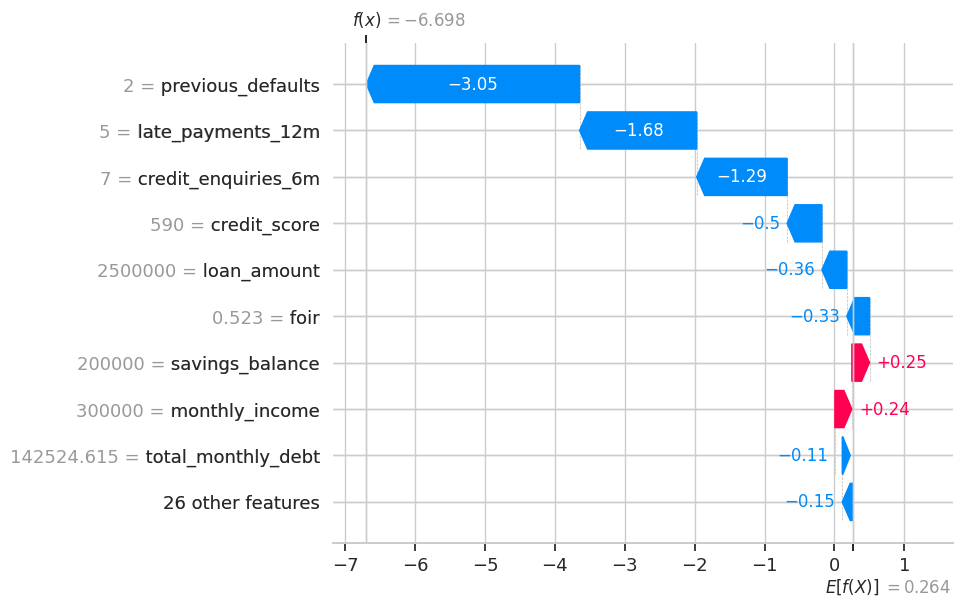


Case 5 — Moderate Income / Strong
Approval Probability: 92.72%
Decision: APPROVED


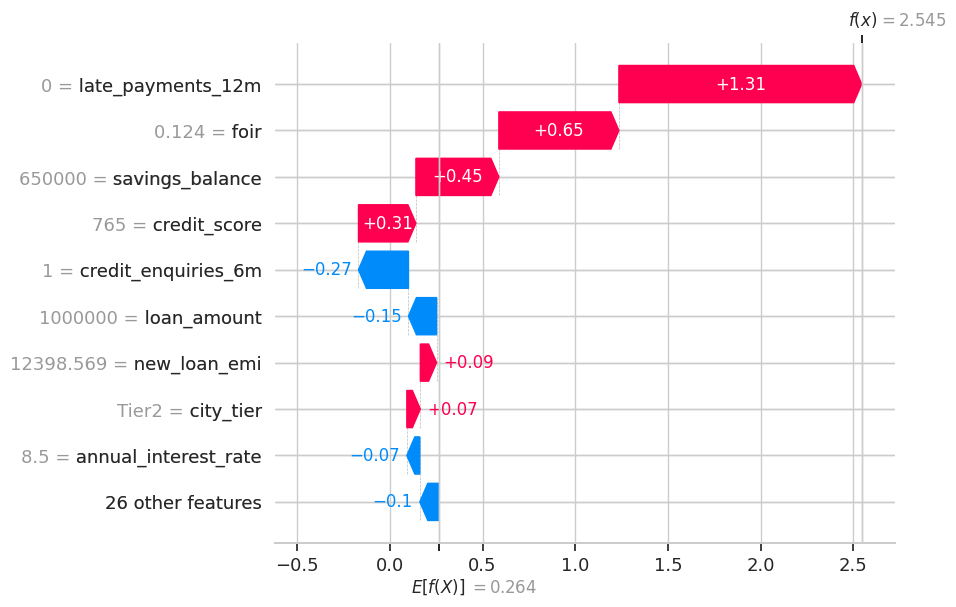

In [45]:
# ============================================================
# SHAP — CURRENTLY LOADED CASES 4 & 5
# ============================================================

import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(final_catboost)
shap_values = explainer.shap_values(X_cases)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

current_case_names = [
    "Case 4 — High Income / Risky",
    "Case 5 — Moderate Income / Strong"
]

for i, name in enumerate(current_case_names):

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    probability = final_catboost.predict_proba(
        X_cases.iloc[[i]]
    )[0, 1]

    decision = "APPROVED" if probability >= 0.45 else "REJECTED"

    print(f"Approval Probability: {probability * 100:.2f}%")
    print(f"Decision: {decision}")

    shap_exp = shap.Explanation(
        values=shap_values[i],
        base_values=explainer.expected_value,
        data=X_cases.iloc[i].values,
        feature_names=X_cases.columns.tolist()
    )

    shap.plots.waterfall(
        shap_exp,
        max_display=10,
        show=True
    )